# Model 5b: Reporting-Aware Shared Difficulty Model

## Overview

This model predicts ultramarathon finish times and DNF (Did Not Finish) rates while accounting for systematic reporting bias in the data. The key innovation is a **shared hierarchical difficulty structure** that couples finish times with DNF probabilities, plus a **reporting probability model** that corrects for courses that don't report DNFs to UltraSignup.

### Core Components

**Hierarchical Difficulty:**
- Course baselines capture the average difficulty of each race course
- Race-specific deviations model year-to-year variation (weather, course changes, etc.)
- The same difficulty parameters influence both finish times and DNF rates

**Reporting Bias Correction:**
- Many courses don't report DNFs, creating two problems:
  1. DNF rates appear artificially low (often 0%)
  2. Finish times are biased fast (missing slower runners who DNF'd)
- Model learns distance-dependent reporting probabilities
- Corrects both DNF estimates and finish time distributions

### Data Sampling

The model uses a hierarchical sampling strategy to balance coverage and statistical power:
- **Course selection:** Popular courses with multiple race instances
- **Race filtering:** Races with sufficient finisher counts for reliable estimation
- **Distance range:** Focus on standard ultra distances (50K through 100+ miles)
- **Total observations:** Thousands of race instances across hundreds of unique courses

### Key Hyperparameters

**Finish Time Model:**
- Gender-specific baseline paces
- Distance scaling coefficients
- Hierarchical variance components (course-level and race-level)

**DNF Model:**
- Baseline DNF rate (distance-adjusted)
- Distance scaling for DNF probability
- Difficulty-DNF coupling parameter (γ)

**Reporting Model:**
- Baseline reporting probability
- Distance-dependent reporting adjustment
- Tighter priors to prevent unrealistic reporting rates

### Why This Model?

Without reporting correction, non-reporting courses appear artificially "easy" (low DNF, fast times). This model disentangles true race difficulty from reporting behavior, enabling fair comparison across all courses and accurate predictions for new races.

## Preamble

### Setup

Import packages, utilities, and configure analysis environment.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from scipy.optimize import minimize
from scipy.stats import linregress
import graphviz
from pathlib import Path
import os
import time
from datetime import datetime

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configure ArviZ
az.style.use("arviz-darkgrid")

# Load our custom utilities
import sys
sys.path.append(os.path.join(os.getcwd()))

from kcore_subsetting import subset_kcore_data
from data_processing import load_results, process_results
from mcmc_notifications import (
    notify_mcmc_start, 
    notify_mcmc_complete, 
    notify_mcmc_error
)
from empirical_priors import (
    calculate_pace_priors,
    calculate_hierarchical_variance_priors,
    calculate_dnf_priors,
    calculate_difficulty_dnf_coupling,
    calculate_reporting_priors
)

# Suppress PyMC sampling messages
import logging
logging.getLogger("pymc").setLevel(logging.ERROR)

print("✓ All imports successful")
print(f"PyMC version: {pm.__version__}")
print(f"ArviZ version: {az.__version__}")

### Data Processing

Load race results database, filter to M/F genders, and create course identifiers (name + distance pooled across years).

In [33]:
# Load and process ALL race results
results = load_results()
results = process_results(results)

# Filter to M and F genders only (exclude X or missing values)
# This is the only filtering we do - NO subsetting yet
results = results[results['gender'].isin(['M', 'F'])].copy()

# Create course identifier using race name + distance (pooled across years)
results['course_id'] = (
    results['name'].astype(str) + '||' + 
    results['distance_miles'].round(1).astype(str)
)

print(f"Total observations: {len(results):,}")
print(f"Gender distribution: {results['gender'].value_counts().to_dict()}")
print(f"Participants: {results['participant_id'].nunique():,}")
print(f"Courses: {results.groupby(['name', 'distance_miles']).ngroups:,}")
print(f"Races (course-year combinations): {results['event_distance_id'].nunique():,}")

Total results: 1,962,927
Finishers: 1,849,053 (94.2%)
DNFs: 113,874 (5.8%)
Total observations: 1,962,224
Gender distribution: {'M': 1232065, 'F': 730159}
Participants: 683,513
Total observations: 1,962,224
Gender distribution: {'M': 1232065, 'F': 730159}
Participants: 683,513
Courses: 7,627
Races (course-year combinations): 30,589
Courses: 7,627
Races (course-year combinations): 30,589


### Model Justification

=== DNF REPORTING STATUS ===
Total courses (n >= 20): 5,930
  Reporting courses (DNF > 0): 3,356 (56.6%)
  Non-reporting courses (DNF = 0): 2,574 (43.4%)

Using reporting courses only for γ estimation (unbiased)

=== JUSTIFICATION: DIFFICULTY-DNF RELATIONSHIP ===
Reporting courses analyzed: 3,356
Correlation (% scales): 0.377 (p=1.621e-113)
Empirical γ (logit scale): 3.033


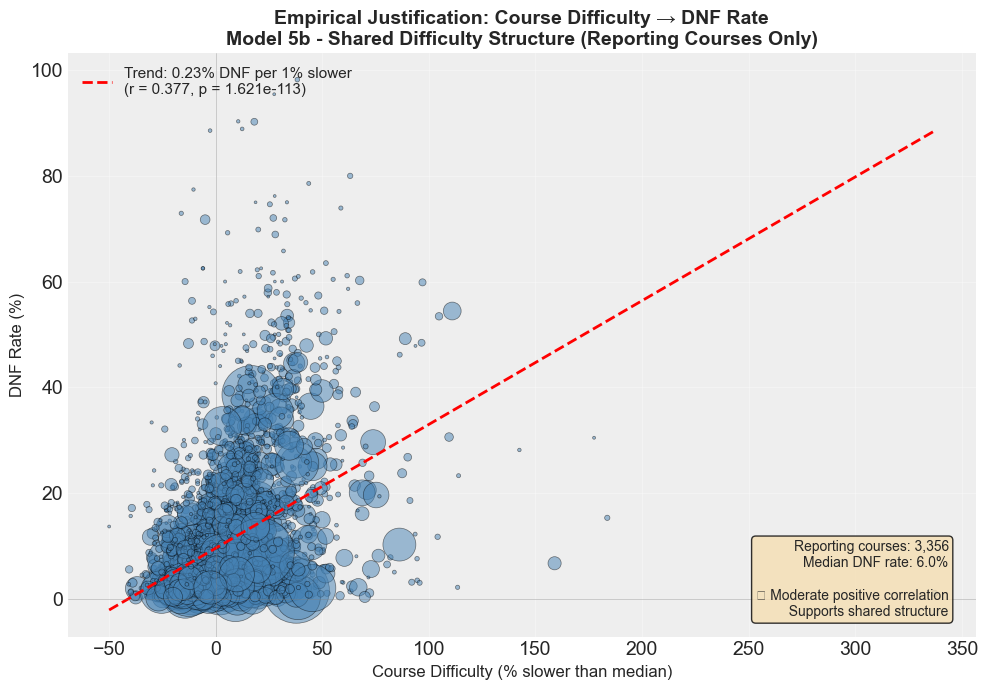


=== REGRESSION STATISTICS (Model parameterization) ===
Linear model on logit scale: logit(DNF) ~ γ * log_pace_residual + intercept
  Slope (γ_empirical): 3.033
  Intercept: -2.916
  R²: 0.143
  P-value: 3.486e-114

=== INTERPRETATION (Percentage scales) ===
✓ For every 1% slower pace, DNF rate increases by ~0.23%
✓ Median DNF rate: 6.0%
✓ DNF rate range: 0.0% - 98.2%
✓ Shared difficulty structure is well supported by data

Note: Using reporting courses only ensures unbiased γ estimation.
      Model accounts for non-reporting via ψ (reporting probability).


In [34]:
# ============================================================================
# CALCULATE COURSE-LEVEL STATISTICS FOR JUSTIFICATION ANALYSIS
# ============================================================================
# KEY: We estimate empirical γ from REPORTING COURSES ONLY (conditional distribution)
# because non-reporting courses have observed_dnf_rate ≈ 0 regardless of difficulty

# Use ALL results data (already filtered to M/F)
results_finishers = results[results['finished']].copy()

# Calculate pace residuals (proxy for course difficulty)
reference_distance = 26.2  # Marathon
results_finishers['pace_min_mi'] = results_finishers['time_ms'] / 60000 / results_finishers['distance_miles']
results_finishers['log_pace'] = np.log(results_finishers['pace_min_mi'])
results_finishers['log_dist_ratio'] = np.log(results_finishers['distance_miles'] / reference_distance)

# Simple gender-specific baseline (for demonstration)
gender_medians = results_finishers.groupby('gender')['log_pace'].median()
results_finishers['log_pace_residual'] = results_finishers.apply(
    lambda x: x['log_pace'] - gender_medians[x['gender']], axis=1
)

# Aggregate course-level statistics
course_stats = results.groupby('course_id').agg({
    'finished': lambda x: (~x).sum(),  # DNF count
    'event_distance_id': 'count'  # Number of results
}).rename(columns={'finished': 'dnf_count', 'event_distance_id': 'n_results'})

# Add median pace residual (course difficulty proxy)
course_median_pace = results_finishers.groupby('course_id')['log_pace_residual'].median()
course_stats['median_log_pace'] = course_median_pace

# Calculate DNF rate
course_stats['dnf_rate'] = course_stats['dnf_count'] / course_stats['n_results']

# Filter to courses with sufficient data
course_stats = course_stats[course_stats['n_results'] >= 20].copy()

# ============================================================================
# FILTER TO REPORTING COURSES (DNF > 0) FOR VALID γ ESTIMATION
# ============================================================================

# Only use courses that report DNFs (conditional distribution)
course_stats_reporting = course_stats[course_stats['dnf_count'] > 0].copy()

print(f"=== DNF REPORTING STATUS ===")
print(f"Total courses (n >= 20): {len(course_stats):,}")
print(f"  Reporting courses (DNF > 0): {len(course_stats_reporting):,} ({100*len(course_stats_reporting)/len(course_stats):.1f}%)")
print(f"  Non-reporting courses (DNF = 0): {len(course_stats) - len(course_stats_reporting):,} ({100*(len(course_stats) - len(course_stats_reporting))/len(course_stats):.1f}%)")
print(f"\nUsing reporting courses only for γ estimation (unbiased)")

# Convert to percentage scale for interpretability
course_stats_reporting['dnf_pct'] = course_stats_reporting['dnf_rate'] * 100

# Convert log pace residual to percentage difference in pace
# log(pace) residual of 0.1 means ~10% slower than median
course_stats_reporting['pace_pct_diff'] = (np.exp(course_stats_reporting['median_log_pace']) - 1) * 100

# Also calculate on logit scale for regression (model uses this)
course_stats_reporting['dnf_rate_clipped'] = course_stats_reporting['dnf_rate'].clip(0.001, 0.999)
course_stats_reporting['logit_dnf'] = np.log(
    course_stats_reporting['dnf_rate_clipped'] / (1 - course_stats_reporting['dnf_rate_clipped'])
)

# ============================================================================
# CALCULATE EMPIRICAL GAMMA (FROM REPORTING COURSES)
# ============================================================================

from scipy.stats import pearsonr, linregress

# Correlation on interpretable scales (for display)
corr_pct, p_value_pct = pearsonr(
    course_stats_reporting['pace_pct_diff'], 
    course_stats_reporting['dnf_pct']
)

# Regression on logit scale (for model parameter γ)
empirical_gamma_m5, intercept, r_value, p_value_reg, std_err = linregress(
    course_stats_reporting['median_log_pace'], 
    course_stats_reporting['logit_dnf']
)

print(f"\n=== JUSTIFICATION: DIFFICULTY-DNF RELATIONSHIP ===")
print(f"Reporting courses analyzed: {len(course_stats_reporting):,}")
print(f"Correlation (% scales): {corr_pct:.3f} (p={p_value_pct:.3e})")
print(f"Empirical γ (logit scale): {empirical_gamma_m5:.3f}")

# ============================================================================
# VISUALIZE EMPIRICAL RELATIONSHIP (INTERPRETABLE SCALES)
# ============================================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Scatter plot: Course difficulty vs DNF rate (PERCENTAGE scales)
ax.scatter(course_stats_reporting['pace_pct_diff'], 
          course_stats_reporting['dnf_pct'],
          alpha=0.5, 
          s=course_stats_reporting['n_results'] / 5,  # Size by number of results
          color='steelblue',
          edgecolor='black',
          linewidth=0.5)

# Add trend line (fit on percentage scales for visualization)
slope_pct, intercept_pct = np.polyfit(
    course_stats_reporting['pace_pct_diff'],
    course_stats_reporting['dnf_pct'],
    deg=1
)
x_line = np.array([course_stats_reporting['pace_pct_diff'].min(), 
                   course_stats_reporting['pace_pct_diff'].max()])
y_line = slope_pct * x_line + intercept_pct
ax.plot(x_line, y_line, 'r--', linewidth=2, 
       label=f'Trend: {slope_pct:.2f}% DNF per 1% slower\n(r = {corr_pct:.3f}, p = {p_value_pct:.3e})')

# Labels and formatting
ax.set_xlabel('Course Difficulty (% slower than median)', fontsize=12)
ax.set_ylabel('DNF Rate (%)', fontsize=12)
ax.set_title('Empirical Justification: Course Difficulty → DNF Rate\n' + 
            'Model 5b - Shared Difficulty Structure (Reporting Courses Only)',
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(alpha=0.3)

# Add reference lines
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

# Add text annotation with interpretation
median_dnf = course_stats_reporting['dnf_pct'].median()
textstr = f'Reporting courses: {len(course_stats_reporting):,}\n'
textstr += f'Median DNF rate: {median_dnf:.1f}%\n\n'
if corr_pct > 0.5:
    textstr += '✓ Strong positive correlation\n  Harder courses → more DNFs'
elif corr_pct > 0.3:
    textstr += '✓ Moderate positive correlation\n  Supports shared structure'
else:
    textstr += '⚠ Weak correlation\n  Shared structure may not fit well'

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.97, 0.03, textstr, transform=ax.transAxes, fontsize=10,
       verticalalignment='bottom', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.show()

# ============================================================================
# PRINT DETAILED STATISTICS
# ============================================================================

print(f"\n=== REGRESSION STATISTICS (Model parameterization) ===")
print(f"Linear model on logit scale: logit(DNF) ~ γ * log_pace_residual + intercept")
print(f"  Slope (γ_empirical): {empirical_gamma_m5:.3f}")
print(f"  Intercept: {intercept:.3f}")
print(f"  R²: {r_value**2:.3f}")
print(f"  P-value: {p_value_reg:.3e}")

print(f"\n=== INTERPRETATION (Percentage scales) ===")
print(f"✓ For every 1% slower pace, DNF rate increases by ~{slope_pct:.2f}%")
print(f"✓ Median DNF rate: {median_dnf:.1f}%")
print(f"✓ DNF rate range: {course_stats_reporting['dnf_pct'].min():.1f}% - {course_stats_reporting['dnf_pct'].max():.1f}%")
print(f"✓ Shared difficulty structure is {'well' if corr_pct > 0.3 else 'weakly'} supported by data")
print(f"\nNote: Using reporting courses only ensures unbiased γ estimation.")
print(f"      Model accounts for non-reporting via ψ (reporting probability).")


## Specification

### Empirical Priors

Calculate data-driven priors for finish time (gender-specific power law), hierarchical variance, DNF rates, and γ (difficulty-DNF coupling).

In [35]:
# ============================================================================
# CALCULATE ALL EMPIRICAL PRIORS FOR MODEL 5 USING MODULAR FUNCTIONS
# ============================================================================

print("=" * 80)
print("CALCULATING EMPIRICAL PRIORS FOR MODEL 5")
print("=" * 80)

# Get finishers for pace calculation
results_finishers = results[results['finished']].copy()
reference_distance = 26.2  # Marathon

# Calculate each type of prior using modular functions
pace_priors = calculate_pace_priors(results_finishers, reference_distance)
hierarchical_priors = calculate_hierarchical_variance_priors(results_finishers, pace_priors, reference_distance)
dnf_priors = calculate_dnf_priors(results, reference_distance)
gamma = calculate_difficulty_dnf_coupling(results, pace_priors, reference_distance)
reporting_priors = calculate_reporting_priors(results, reference_distance)

print("\n" + "=" * 80)
print("✓ All empirical priors calculated successfully")
print("=" * 80)

CALCULATING EMPIRICAL PRIORS FOR MODEL 5
📊 M pace priors:
   Marathon pace: 14.76 min/mile
   Log marathon pace: 2.692
   Beta (power law): 0.1118
   Between-participant log-pace SD: 0.276
📊 M pace priors:
   Marathon pace: 14.76 min/mile
   Log marathon pace: 2.692
   Beta (power law): 0.1118
   Between-participant log-pace SD: 0.276
📊 F pace priors:
   Marathon pace: 15.84 min/mile
   Log marathon pace: 2.762
   Beta (power law): 0.0531
   Between-participant log-pace SD: 0.265
📊 F pace priors:
   Marathon pace: 15.84 min/mile
   Log marathon pace: 2.762
   Beta (power law): 0.0531
   Between-participant log-pace SD: 0.265

📊 Hierarchical variance priors:
   sigma_course: 0.124
   sigma_race: 0.178

📊 Hierarchical variance priors:
   sigma_course: 0.124
   sigma_race: 0.178

📊 DNF priors:
   mu_logit_dnf: -3.6905 (DNF rate at 26.2 mi: 2.4%)
   beta_dist_dnf: 1.3169
   sigma_course_dnf: 1.445

📊 DNF priors:
   mu_logit_dnf: -3.6905 (DNF rate at 26.2 mi: 2.4%)
   beta_dist_dnf: 1.3169


In [36]:
# Extract individual prior values for use in model definition
# (maintaining backward compatibility with existing code)

# Hierarchical variance
prior_sigma_course = hierarchical_priors['sigma_course']
prior_sigma_race = hierarchical_priors['sigma_race']

# DNF model baseline
prior_mu_logit_dnf = dnf_priors['mu_logit_dnf']
prior_beta_dist_dnf = dnf_priors['beta_dist_dnf']

# Difficulty-DNF coupling
prior_gamma = gamma

# Reporting probability (SIMPLE BASELINE - size effects handled by likelihood)
prior_logit_psi = reporting_priors['logit_psi']
prior_psi = reporting_priors['psi']

# Create empirical_priors_m5 dict for gender-specific pace priors (for model definition)
empirical_priors_m5 = pace_priors

print("\n=== EXTRACTED PRIORS (READY FOR MODEL) ===")
print(f"\n1. HIERARCHICAL VARIANCE:")
print(f"   sigma_course: {prior_sigma_course:.3f}")
print(f"   sigma_race: {prior_sigma_race:.3f}")

print(f"\n2. DNF MODEL BASELINE:")
print(f"   mu_logit_dnf: {prior_mu_logit_dnf:.3f}")
print(f"   beta_dist_dnf: {prior_beta_dist_dnf:.3f}")

print(f"\n3. DIFFICULTY-DNF COUPLING:")
print(f"   gamma: {prior_gamma:.3f}")

print(f"\n4. REPORTING PROBABILITY (BASELINE ONLY):")
print(f"   logit_psi: {prior_logit_psi:.3f}")
print(f"   psi: {prior_psi:.1%} (global baseline)")
print(f"   Note: Size effects emerge naturally from Bayesian likelihood")

print(f"\n5. FINISH TIME MODEL (GENDER-SPECIFIC):")
for gender in ['M', 'F']:
    priors = empirical_priors_m5[gender]
    print(f"   {gender}: log_marathon_pace={priors['log_marathon_pace']:.3f}, "
          f"beta={priors['beta']:.3f}, "
          f"log_pace_sd={priors['log_pace_sd']:.3f}")


=== EXTRACTED PRIORS (READY FOR MODEL) ===

1. HIERARCHICAL VARIANCE:
   sigma_course: 0.124
   sigma_race: 0.178

2. DNF MODEL BASELINE:
   mu_logit_dnf: -3.690
   beta_dist_dnf: 1.317

3. DIFFICULTY-DNF COUPLING:
   gamma: 0.364

4. REPORTING PROBABILITY (BASELINE ONLY):
   logit_psi: 0.592
   psi: 64.4% (global baseline)
   Note: Size effects emerge naturally from Bayesian likelihood

5. FINISH TIME MODEL (GENDER-SPECIFIC):
   M: log_marathon_pace=2.692, beta=0.112, log_pace_sd=0.276
   F: log_marathon_pace=2.762, beta=0.053, log_pace_sd=0.265


### K-Core Data Subsetting

Use k-core decomposition to find a densely-connected subset of runners and courses for efficient Bayesian inference. The k-core approach:

1. **Finds symmetric (k,k)-core**: All runners have ≥k results, all courses have ≥k runners
2. **Adds tiered closure**: Selectively includes sparse entities highly connected to core
3. **Flags data types**: `in_kcore` (dense, complete) vs `in_closure` (sparse, linked to core)

This enables **two-stage modeling**:
- **Stage 1 MCMC**: High-quality posteriors on k-core entities (complete data)
- **Stage 2 MAP**: Fix core params, estimate closure params using Stage 1 as priors

In [ ]:
# K-core parameters chosen from kcore_optimization.ipynb Pareto frontier
# TODO: Update these values based on your Pareto frontier analysis
alpha = 5  # Minimum courses per k-core runner
beta = 25  # Minimum runners per k-core course

# Apply k-core flagging with course-completion closure
from utils.kcore_subsetting import subset_kcore_data
results = subset_kcore_data(results, alpha=alpha, beta=beta)
model_data = results[results['in_kcore'] | results['in_closure']]

print(f"\n{'='*80}")
print(f"SUBSET SUMMARY")
print(f"{'='*80}")
print(f"K-core subset (α={alpha}, β={beta}):")
print(f"  K-core results: {results['in_kcore'].sum():,}")
print(f"  Closure results: {results['in_closure'].sum():,}")
print(f"  Total for modeling: {len(model_data):,} (down from {len(results):,})")
print(f"  K-core courses: {results[results['in_kcore']]['name'].nunique():,}")
print(f"  K-core runners: {results[results['in_kcore']]['participant_id'].nunique():,}")
print(f"\nParticipants: {model_data['participant_id'].nunique():,}")
print(f"Courses: {model_data.groupby(['name', 'distance_miles']).ngroups:,}")
print(f"Races: {model_data['event_distance_id'].nunique():,}")


K-CORE SUBSET with max 6,000 entities

📊 Building bipartite graph...
   662,235 runners
   7,608 courses
   1,454,241 results (edges)

🔍 Finding densest k-core...
   Phase 1: Symmetric (k,k) search starting from k=20...
   662,235 runners
   7,608 courses
   1,454,241 results (edges)

🔍 Finding densest k-core...
   Phase 1: Symmetric (k,k) search starting from k=20...
      k=20: 1,760 entities ✅
      k=20: 1,760 entities ✅
      k=21: 434 entities ✅
      k=21: 434 entities ✅
      k=22: 0 entities - EMPTY, stopping symmetric search

   Phase 2: Asymmetric (α,β) search from base k=21...
      k=22: 0 entities - EMPTY, stopping symmetric search

   Phase 2: Asymmetric (α,β) search from base k=21...
      α=22, β=21: EMPTY, stopping α search
      α=22, β=21: EMPTY, stopping α search
      α=21, β=22: EMPTY, stopping β search
   ✅ Found k=21 core:
      Runners: 291
      Courses: 143
      Total: 434 entities

🎯 Adding tiered closure (budget: 6,000 total entities)...
   Closure candi

### Generative Model

**Complete mathematical specification with hierarchical structure, shared difficulty parameters, and reporting bias correction.**

---

#### Hierarchical Difficulty Structure

The same latent difficulty variables drive both finish times and DNF probabilities:

```
course_baseline[c] ~ Normal(0, σ_course)
race_difficulty[r] ~ Normal(course_baseline[parent_course[r]], σ_race)
```

Where:
- `σ_course` controls variation across different race courses
- `σ_race` controls year-to-year variation within the same course

---

#### Finish Time Model

For finisher `i` in race `r` at distance `d`:

```
log_pace[i] = mu_pace[gender[i]] + beta[gender[i]] * log(d / d_marathon) + race_difficulty[r] + ε
ε ~ Normal(0, σ_obs)
```

**Priors:**
- `mu_pace[gender]` ~ Normal(empirical, 0.2) - Gender-specific baseline log-pace at marathon distance
- `beta[gender]` ~ Normal(empirical, 0.1) - Gender-specific distance scaling
- `σ_obs` ~ HalfNormal(empirical) - Within-race variation
- `σ_course` ~ HalfNormal(empirical) - Between-course variation
- `σ_race` ~ HalfNormal(empirical) - Between-race (within-course) variation

All empirical priors derived from data to provide informed regularization.

---

#### DNF Model with Difficulty Coupling

For result `i` in race `r` at distance `d`:

```
logit(P(DNF)[i]) = mu_dnf + beta_dist * log(d / d_marathon) + γ * race_difficulty[r]
                                                                ^^^^^^^^^^^^^^^^^^^
                                                                Shared with finish times!
```

**Priors:**
- `mu_dnf` ~ Normal(empirical, 1.0) - Baseline logit-DNF at marathon distance  
- `beta_dist` ~ Normal(empirical, 0.5) - Distance effect on DNF
- `γ` ~ Normal(empirical, 0.5) - **Difficulty-DNF coupling** (harder races → more DNFs)

---

#### Reporting Probability Model

Longer races are more likely to report DNFs (ultras track carefully, road races often don't):

```
logit(psi[d]) = logit_psi_baseline + beta_psi_dist * log(d / d_marathon)
```

**Priors:**
- `logit_psi_baseline` ~ Normal(-0.4, 0.3) → psi_marathon ≈ 40% (95% CI: 30-55%)
- `beta_psi_dist` ~ Normal(1.0, 0.5) → Positive slope (longer = higher reporting)

**Course-specific reporting:**
```
reporting_prob[c] = 1.0                    if observed_dnf_count[c] > 0
                  = psi[distance[c]]       if observed_dnf_count[c] = 0
```

Courses with ANY observed DNFs definitely report. Courses with ZERO observed DNFs use the distance-dependent prior.

---

#### Zero-Inflated Likelihood

**For DNF observations:**
```
P(observe finish) = reporting_prob[c] * P(true finish) + (1 - reporting_prob[c]) * 1.0
                  = reporting_prob[c] * (1 - P(DNF)) + (1 - reporting_prob[c])
```

This creates a mixture:
- With probability `reporting_prob[c]`: observe true outcome
- With probability `1 - reporting_prob[c]`: always observe "finish" (DNF not recorded)

**For finish times (censoring correction):**

Courses with zero observed DNFs have biased finish time distributions (missing slow DNFs). Add log-likelihood penalty:

```
For courses with observed_dnf_count[c] = 0:
  censoring_penalty = -n_finishers[c] * log(E[P(finish)] * psi[d])
```

Where `E[P(finish)]` is the expected finish probability for that course's finishers under the model. This corrects the finish time likelihood for the censored slow finishers who DNF'd but weren't recorded.

---

#### Model Summary

**Total parameters:**
- 10 hyperparameters (pace, DNF, reporting models)
- ~1,000 course baseline effects
- ~2,500 race difficulty effects

The model jointly estimates finish time distributions and DNF probabilities while correcting for reporting bias, enabling fair comparison across all courses regardless of reporting practices.

In [38]:
# ============================================================================
# INDEX MAPPINGS
# ============================================================================

# Create course identifier using race name + distance (pooled across years)
model_data['course_id'] = (
    model_data['name'].astype(str) + '||' + 
    model_data['distance_miles'].round(1).astype(str)
)

# Create course and race index mappings
unique_courses_m5 = model_data['course_id'].unique()
course_id_to_idx_m5 = {cid: idx for idx, cid in enumerate(unique_courses_m5)}
model_data['course_idx'] = model_data['course_id'].map(course_id_to_idx_m5)

# Create race index mapping (event_distance_id is unique per year)
unique_races_m5 = model_data['event_distance_id'].unique()
race_id_to_idx_m5 = {rid: idx for idx, rid in enumerate(unique_races_m5)}
model_data['race_idx'] = model_data['event_distance_id'].map(race_id_to_idx_m5)

# Create race-to-course mapping for hierarchical structure
race_to_course_m5 = np.array([
    course_id_to_idx_m5[model_data[model_data['event_distance_id'] == rid]['course_id'].iloc[0]]
    for rid in unique_races_m5
])

# Create gender index mapping
unique_genders = np.array(['M', 'F'])
gender_to_idx = {'M': 0, 'F': 1}
model_data['gender_idx'] = model_data['gender'].map(gender_to_idx)

# ============================================================================
# DATA ARRAYS
# ============================================================================

# Dimensions
n_courses_m5 = len(unique_courses_m5)
n_races_m5 = len(unique_races_m5)
n_genders = len(unique_genders)
n_results_m5 = len(model_data)

# Finisher data
model_data_finishers_m5 = model_data[model_data['finished']].copy()
model_data_finishers_m5['pace_min_mi'] = model_data_finishers_m5['time_ms'] / 60000 / model_data_finishers_m5['distance_miles']
model_data_finishers_m5['log_pace'] = np.log(model_data_finishers_m5['pace_min_mi'])
model_data_finishers_m5['log_dist_ratio'] = np.log(model_data_finishers_m5['distance_miles'] / reference_distance)
model_data_finishers_m5['course_idx'] = model_data_finishers_m5['course_id'].map(course_id_to_idx_m5)
model_data_finishers_m5['race_idx'] = model_data_finishers_m5['event_distance_id'].map(race_id_to_idx_m5)
model_data_finishers_m5['gender_idx'] = model_data_finishers_m5['gender'].map(gender_to_idx)

n_finishers_m5 = len(model_data_finishers_m5)

# ALL RESULTS (DNF + Finisher arrays)
course_indices_results_m5 = model_data['course_idx'].values
race_indices_results_m5 = model_data['race_idx'].values
gender_indices_results_m5 = model_data['gender_idx'].values
distances_results_m5 = model_data['distance_miles'].values
log_dist_ratios_results_m5 = np.log(distances_results_m5 / reference_distance)
finished_results_m5 = model_data['finished'].values.astype(int)

# FINISHER-ONLY ARRAYS
course_indices_finishers_m5 = model_data_finishers_m5['course_idx'].values
race_indices_finishers_m5 = model_data_finishers_m5['race_idx'].values
gender_indices_finishers_m5 = model_data_finishers_m5['gender_idx'].values
distances_finishers_m5 = model_data_finishers_m5['distance_miles'].values
log_dist_ratios_finishers_m5 = model_data_finishers_m5['log_dist_ratio'].values
log_pace_finishers_m5 = model_data_finishers_m5['log_pace'].values

print(f"=== DATA DIMENSIONS ===")
print(f"Total results (DNF + finishers): {n_results_m5:,}")
print(f"  Finishers: {n_finishers_m5:,} ({100*n_finishers_m5/n_results_m5:.1f}%)")
print(f"  DNFs: {n_results_m5 - n_finishers_m5:,} ({100*(n_results_m5 - n_finishers_m5)/n_results_m5:.1f}%)")
print(f"\nCourses: {n_courses_m5:,}")
print(f"Races (course-year combinations): {n_races_m5:,}")
print(f"Genders: {n_genders}")
print(f"Participants: {model_data['participant_id'].nunique():,}")

print(f"\n=== HIERARCHICAL STRUCTURE ===")
print(f"Race-to-course mapping: {len(race_to_course_m5):,} races mapped to {n_courses_m5:,} courses")
print(f"Average races per course: {n_races_m5 / n_courses_m5:.1f}")

# Verify no missing indices
assert model_data['course_idx'].isna().sum() == 0, "Missing course indices"
assert model_data['race_idx'].isna().sum() == 0, "Missing race indices"
assert model_data['gender_idx'].isna().sum() == 0, "Missing gender indices"
print(f"\n✓ Index mapping validated: No missing values")

# Verify race-to-course mapping
for race_idx, course_idx in enumerate(race_to_course_m5):
    race_id = unique_races_m5[race_idx]
    actual_course_id = model_data[model_data['event_distance_id'] == race_id]['course_id'].iloc[0]
    actual_course_idx = course_id_to_idx_m5[actual_course_id]
    assert course_idx == actual_course_idx, f"Race-to-course mapping error for race {race_id}"
print(f"✓ Race-to-course mapping validated")

# Summary statistics by course
course_summary_m5 = model_data.groupby('course_id').agg({
    'event_distance_id': 'nunique',  # Number of race instances (years)
    'participant_id': 'nunique',  # Unique participants
    'finished': ['sum', 'count']  # Finishers and total results
}).reset_index()
course_summary_m5.columns = ['course_id', 'n_races', 'n_participants', 'n_finishers', 'n_results']
course_summary_m5['finish_rate'] = course_summary_m5['n_finishers'] / course_summary_m5['n_results']

print(f"\n=== COURSE SUMMARY STATISTICS ===")
print(f"Median races per course: {course_summary_m5['n_races'].median():.0f}")
print(f"Median participants per course: {course_summary_m5['n_participants'].median():.0f}")
print(f"Median results per course: {course_summary_m5['n_results'].median():.0f}")
print(f"Median finish rate: {course_summary_m5['finish_rate'].median():.1%}")

# Display top courses by result count
print(f"\n=== TOP 10 COURSES BY RESULT COUNT ===")
top_courses = course_summary_m5.nlargest(10, 'n_results')[['course_id', 'n_races', 'n_participants', 'n_results', 'finish_rate']]
for idx, row in top_courses.iterrows():
    course_name = row['course_id'].split('||')[0][:40]  # Truncate long names
    print(f"{course_name:40s} | Races: {row['n_races']:3.0f} | Participants: {row['n_participants']:5.0f} | Results: {row['n_results']:6.0f} | Finish: {row['finish_rate']:5.1%}")


=== DATA DIMENSIONS ===
Total results (DNF + finishers): 135,487
  Finishers: 127,249 (93.9%)
  DNFs: 8,238 (6.1%)

Courses: 616
Races (course-year combinations): 5,705
Genders: 2
Participants: 5,384

=== HIERARCHICAL STRUCTURE ===
Race-to-course mapping: 5,705 races mapped to 616 courses
Average races per course: 9.3

✓ Index mapping validated: No missing values
✓ Race-to-course mapping validated

=== COURSE SUMMARY STATISTICS ===
Median races per course: 7
Median participants per course: 58
Median results per course: 76
Median finish rate: 99.0%

=== TOP 10 COURSES BY RESULT COUNT ===
Western States - 100 Miler               | Races:  47 | Participants:  2379 | Results:   5081 | Finish: 91.7%
Quad Dipsea - 28.4 Miler                 | Races:  40 | Participants:  1271 | Results:   4520 | Finish: 97.9%
Skyline 50k Endurance Run - 50K          | Races:  41 | Participants:  1377 | Results:   3702 | Finish: 98.9%
Dick Collins Firetrails - 50 Miler       | Races:  39 | Participants:  1480 

In [39]:
# Create additional arrays and coordinates needed for Model 5

# Create coordinate labels for interpretability
course_coords_m5 = [f"Course_{i}" for i in range(n_courses_m5)]
race_coords_m5 = [f"Race_{i}" for i in range(n_races_m5)]

# Create did_finish_m5 from finished_results_m5 (fix naming inconsistency)
did_finish_m5 = finished_results_m5

# Create observed_times_finishers_m5 from time data
observed_times_finishers_m5 = model_data_finishers_m5['time_ms'].values / 60000  # Convert to minutes

print(f"=== ADDITIONAL MODEL VARIABLES CREATED ===")
print(f"Course coordinates: {len(course_coords_m5):,}")
print(f"Race coordinates: {len(race_coords_m5):,}")
print(f"Finish/DNF indicator: {len(did_finish_m5):,} results")
print(f"Observed times (finishers only): {len(observed_times_finishers_m5):,} times")
print(f"  Range: {observed_times_finishers_m5.min():.1f} - {observed_times_finishers_m5.max():.1f} minutes")

=== ADDITIONAL MODEL VARIABLES CREATED ===
Course coordinates: 616
Race coordinates: 5,705
Finish/DNF indicator: 135,487 results
Observed times (finishers only): 127,249 times
  Range: 33.2 - 33551.0 minutes


In [40]:
# ============================================================================
# IDENTIFY NON-REPORTING COURSES EMPIRICALLY (FULLY VECTORIZED)
# ============================================================================

# Compute DNF count per course (vectorized aggregation)
course_dnf_counts_m5 = model_data.groupby('course_id', observed=False)['finished'].agg(['sum', 'count']).reset_index()
course_dnf_counts_m5.columns = ['course_id', 'n_finished', 'n_total']
course_dnf_counts_m5['n_dnf'] = course_dnf_counts_m5['n_total'] - course_dnf_counts_m5['n_finished']

# FULLY VECTORIZED: Use pandas Series with reindex (preserves order of unique_courses_m5)
course_dnf_series = course_dnf_counts_m5.set_index('course_id')['n_dnf']
observed_dnf_count_per_course = course_dnf_series.reindex(unique_courses_m5).values

# Statistics
n_courses_with_dnf = (observed_dnf_count_per_course > 0).sum()
n_courses_zero_dnf = (observed_dnf_count_per_course == 0).sum()

print("=" * 80)
print("NON-REPORTING COURSE IDENTIFICATION")
print("=" * 80)
print(f"Total courses in model: {n_courses_m5:,}")
print(f"  Courses with ANY DNFs: {n_courses_with_dnf:,} ({100*n_courses_with_dnf/n_courses_m5:.1f}%)")
print(f"  Courses with ZERO DNFs: {n_courses_zero_dnf:,} ({100*n_courses_zero_dnf/n_courses_m5:.1f}%)")
print(f"\n✓ Distance-dependent reporting probability will handle non-reporters")
print(f"✓ All {n_courses_m5:,} courses kept in dataset")

NON-REPORTING COURSE IDENTIFICATION
Total courses in model: 616
  Courses with ANY DNFs: 332 (53.9%)
  Courses with ZERO DNFs: 284 (46.1%)

✓ Distance-dependent reporting probability will handle non-reporters
✓ All 616 courses kept in dataset


In [47]:
# ============================================================================
# MODEL 5C: REPORTING-AWARE SHARED DIFFICULTY MODEL (FIXED CIRCULAR DEPENDENCY)
# ============================================================================
# This model accounts for courses that don't report DNFs to UltraSignup
# using a BASELINE reporting probability (organizational characteristic)
#
# KEY FEATURES:
# 1. Shared difficulty structure (race_difficulty affects both pace and DNF)
# 2. Baseline reporting probability: psi = sigmoid(logit_psi)
# 3. Zero-inflated DNF model: P(observe DNF) = reporting_prob * P(true DNF)
# 4. FIXED: Selection correction uses EXPECTED DNF (no race_difficulty) to break circular dependency
# 5. SIZE EFFECTS HANDLED NATURALLY: P(0 DNFs | reports, n) = (1-p_dnf)^n in Bayesian likelihood
# 6. Only +1 parameter vs Model 5 (logit_psi)
# 7. UPDATED: Deterministic reporting probability - courses with ANY DNFs definitely report (psi = 1.0)
# 8. UPDATED: Explicit Bernoulli likelihood for zero-DNF courses based on distance-specific DNF rate

# Get distance per course for expected DNF probability calculation
course_distances_m5 = np.array([
    model_data[model_data['course_id'] == cid]['distance_miles'].iloc[0]
    for cid in unique_courses_m5
])

# Get number of results per course for Bernoulli likelihood
n_results_per_course = np.array([
    len(model_data[model_data['course_id'] == cid])
    for cid in unique_courses_m5
])

coords_m5 = {
    "course": course_coords_m5,
    "race": race_coords_m5,
    "gender": unique_genders,
    "finishers": range(n_finishers_m5),
    "results": range(n_results_m5)
}

with pm.Model(coords=coords_m5) as model_m5:
    
    # ========================================================================
    # FINISH TIME MODEL (SAME AS MODEL 5)
    # ========================================================================
    
    # Population-level baseline pace at marathon distance (GENDER-SPECIFIC)
    mu_pace = pm.Normal(
        "mu_pace",
        mu=np.array([empirical_priors_m5[g]['log_marathon_pace'] for g in unique_genders]),
        sigma=np.array([empirical_priors_m5[g]['log_pace_sd'] for g in unique_genders]),
        dims="gender"
    )
    
    # Distance scaling exponent (GENDER-SPECIFIC)
    beta = pm.Normal(
        "beta",
        mu=np.array([empirical_priors_m5[g]['beta'] for g in unique_genders]),
        sigma=0.05,
        dims="gender"
    )
    
    # Variance components for hierarchical structure
    sigma_course = pm.HalfNormal("sigma_course", sigma=prior_sigma_course)
    sigma_race = pm.HalfNormal("sigma_race", sigma=prior_sigma_race)
    sigma_obs = pm.HalfNormal(
        "sigma_obs", 
        sigma=np.array([empirical_priors_m5[g]['log_pace_sd'] for g in unique_genders]),
        dims="gender"
    )
    
    # PARENT LEVEL: Course baseline effects (non-centered parameterization)
    course_baseline_raw = pm.Normal("course_baseline_raw", mu=0, sigma=1, dims="course")
    course_baseline = pm.Deterministic(
        "course_baseline",
        sigma_course * course_baseline_raw,
        dims="course"
    )
    
    # CHILD LEVEL: Race difficulty (HIERARCHICALLY NESTED)
    # This is SHARED between finish time and DNF models
    race_difficulty_raw = pm.Normal("race_difficulty_raw", mu=0, sigma=1, dims="race")
    race_difficulty = pm.Deterministic(
        "race_difficulty",
        course_baseline[race_to_course_m5] + sigma_race * race_difficulty_raw,
        dims="race"
    )
    
    # Expected pace model (power law with hierarchical difficulty)
    # OPTIMIZATION: Use pre-computed log distance ratios
    log_distance_ratio_finishers = log_dist_ratios_finishers_m5
    
    log_expected_pace = (
        mu_pace[gender_indices_finishers_m5] +
        beta[gender_indices_finishers_m5] * log_distance_ratio_finishers +
        race_difficulty[race_indices_finishers_m5]
    )
    
    # Observed pace (finishers only)
    observed_pace_finishers = observed_times_finishers_m5 / distances_finishers_m5
    
    # Likelihood for finish times (finishers only)
    pace_likelihood = pm.LogNormal(
        "pace_likelihood",
        mu=log_expected_pace,
        sigma=sigma_obs[gender_indices_finishers_m5],
        observed=observed_pace_finishers,
        dims="finishers"
    )
    
    # ========================================================================
    # DNF MODEL PARAMETERS (DEFINED FIRST - NEEDED FOR REPORTING MODEL)
    # ========================================================================
    
    # Population-level baseline DNF probability (logit scale)
    mu_logit_dnf = pm.Normal("mu_logit_dnf", mu=prior_mu_logit_dnf, sigma=0.5)
    
    # Distance effect on DNF probability (linear)
    beta_dist_dnf = pm.Normal("beta_dist_dnf", mu=prior_beta_dist_dnf, sigma=0.4)
    
    # Distance effect on DNF probability (quadratic)
    beta_dist_dnf_quad = pm.Normal("beta_dist_dnf_quad", mu=0.5, sigma=0.3)
    
    # Difficulty-DNF coupling strength (gamma)
    gamma = pm.TruncatedNormal(
        "gamma",
        mu=prior_gamma,
        sigma=0.5,
        lower=0
    )
    
    # ========================================================================
    # DNF REPORTING MODEL - DETERMINISTIC WITH BAYESIAN INFERENCE FOR UNCERTAIN CASES
    # ========================================================================
    
    # KEY INSIGHT: Two types of courses based on OBSERVED data:
    # 1. ANY DNFs observed → DEFINITELY reports (psi = 1.0) - no inference needed
    # 2. ZERO DNFs observed → UNCERTAIN reporting status - infer via Bayesian likelihood
    #
    # For type 2, posterior psi depends on:
    # - Prior psi (baseline organizational probability)
    # - Bernoulli likelihood: P(0 DNFs | reports, n_results, p_DNF_distance)
    # - Larger n_results → stronger evidence that zero DNFs means non-reporting
    # - Higher p_DNF at that distance → stronger evidence that zero DNFs means non-reporting
    
    # Baseline reporting probability (only applies to courses with zero DNFs)
    logit_psi = pm.Normal("logit_psi", mu=prior_logit_psi, sigma=0.5)
    psi = pm.Deterministic("psi", pm.math.sigmoid(logit_psi))  # FIXED: Make it Deterministic so it's saved to trace
    
    # Calculate EXPECTED DNF probability for each course (distance-dependent only)
    # This is used for the Bernoulli likelihood for courses with zero observed DNFs
    log_dist_ratio_per_course = np.log(course_distances_m5 / reference_distance)
    logit_expected_dnf_per_course = (
        mu_logit_dnf +
        beta_dist_dnf * log_dist_ratio_per_course +
        beta_dist_dnf_quad * log_dist_ratio_per_course**2
    )
    expected_dnf_prob_per_course = pm.math.sigmoid(logit_expected_dnf_per_course)
    
    # Course-level reporting probability (DETERMINISTIC RULE + BAYESIAN INFERENCE)
    # If course has ANY observed DNFs → definitely reports (reporting_prob = 1.0)
    # If course has ZERO observed DNFs → inferred via Bayesian likelihood
    reporting_prob_course = pm.Deterministic(
        "reporting_prob_course",
        pm.math.switch(
            observed_dnf_count_per_course > 0,
            1.0,           # Has DNFs → definitely reporting
            psi            # Zero DNFs → infer from baseline psi
        ),
        dims="course"
    )
    
    # ========================================================================
    # BERNOULLI LIKELIHOOD FOR ZERO-DNF COURSES
    # ========================================================================
    # For courses with zero observed DNFs, add explicit likelihood term:
    # P(0 DNFs | reports, n, p_dnf) = (1 - p_dnf)^n
    #
    # This penalizes the "reports" hypothesis for courses with:
    # - Large n (many results but zero DNFs)
    # - High expected p_dnf at that distance
    #
    # The switch ensures this only applies to courses with zero DNFs
    # (courses with DNFs already have psi=1.0, so this term doesn't affect them)
    
    # Mask for courses with zero DNFs
    zero_dnf_mask = observed_dnf_count_per_course == 0
    
    # For zero-DNF courses: probability of observing zero DNFs if they report
    # P(0 DNFs | reports) = (1 - p_dnf)^n
    prob_zero_dnf_if_reporting = pm.math.switch(
        zero_dnf_mask,
        (1 - expected_dnf_prob_per_course)**n_results_per_course,  # Zero DNFs: apply likelihood
        1.0  # Has DNFs: no contribution (already deterministic psi=1)
    )
    
    # Bernoulli likelihood for reporting probability
    # For zero-DNF courses: P(observe 0 DNFs) = psi * (1-p_dnf)^n + (1-psi) * 1
    # For courses with DNFs: psi = 1.0 (deterministic), so this becomes a constant
    pm.Potential(
        "zero_dnf_likelihood",
        pm.math.log(
            reporting_prob_course * prob_zero_dnf_if_reporting + 
            (1 - reporting_prob_course) * 1.0
        ).sum()
    )
    
    # Map to result-level (for DNF likelihood)
    reporting_prob_results = reporting_prob_course[course_indices_results_m5]
    
    # ========================================================================
    # DNF MODEL (ZERO-INFLATED WITH SHARED DIFFICULTY)
    # ========================================================================
    
    # TRUE DNF probability (latent - what we want to estimate)
    # Uses SHARED race_difficulty from finish time model
    logit_true_dnf = (
        mu_logit_dnf + 
        beta_dist_dnf * log_dist_ratios_results_m5 +
        beta_dist_dnf_quad * log_dist_ratios_results_m5**2 +
        gamma * race_difficulty[race_indices_results_m5]
    )
    true_dnf_prob = pm.math.sigmoid(logit_true_dnf)
    
    # OBSERVED DNF probability (accounting for reporting)
    # P(observed_DNF) = P(reports) * P(true_DNF)
    observed_dnf_prob = pm.Deterministic(
        "observed_dnf_prob",
        reporting_prob_results * true_dnf_prob,
        dims="results"
    )
    
    # Complement: finish probability
    finish_prob = 1 - observed_dnf_prob
    
    # Likelihood for finish/DNF outcome (all results)
    finish_likelihood = pm.Bernoulli(
        "finish_likelihood",
        p=finish_prob,
        observed=did_finish_m5,
        dims="results"
    )
    
    # ========================================================================
    # CENSORING CORRECTION FOR FINISH TIMES (FIXED: BREAK CIRCULAR DEPENDENCY)
    # ========================================================================
    
    # Step 1: Calculate EXPECTED P(DNF) for each finisher (distance-dependent only)
    logit_dnf_expected = (
        mu_logit_dnf + 
        beta_dist_dnf * log_dist_ratios_finishers_m5 +
        beta_dist_dnf_quad * log_dist_ratios_finishers_m5**2
    )
    expected_dnf_prob_finishers = pm.math.sigmoid(logit_dnf_expected)
    expected_finish_prob_finishers = 1 - expected_dnf_prob_finishers
    
    # Step 2: Get reporting probability for each finisher's course
    reporting_prob_finishers = reporting_prob_course[course_indices_finishers_m5]
    
    # Step 3: Calculate selection probability using EXPECTED finish probability
    selection_prob = reporting_prob_finishers * expected_finish_prob_finishers + (1 - reporting_prob_finishers)
    
    # Step 4: Apply selection weight to likelihood
    selection_weight = 1 / selection_prob
    pm.Potential("selection_correction", pm.math.log(selection_weight))

print(f"✅ Model 5c defined with deterministic reporting probability + Bernoulli likelihood")
print(f"   Courses with DNFs: {n_courses_with_dnf:,} → psi = 1.0 (deterministic)")
print(f"   Courses with zero DNFs: {n_courses_zero_dnf:,} → psi inferred via Bernoulli(p=(1-p_dnf)^n)")
print(f"   Distance-specific DNF rates used for zero-DNF course likelihood")
print(f"   Total parameters: {10} hyperparameters + {n_courses_m5:,} courses + {n_races_m5:,} races")

✅ Model 5c defined with deterministic reporting probability + Bernoulli likelihood
   Courses with DNFs: 332 → psi = 1.0 (deterministic)
   Courses with zero DNFs: 284 → psi inferred via Bernoulli(p=(1-p_dnf)^n)
   Distance-specific DNF rates used for zero-DNF course likelihood
   Total parameters: 10 hyperparameters + 616 courses + 5,705 races


In [48]:
# Pre-compute logarithmic distance ratios (constant transformations)
# These are used multiple times in the model but depend only on data, not parameters
# Pre-computing reduces redundant PyMC operations during MCMC sampling

# For finishers (used in pace model and selection correction)
log_dist_ratios_finishers_m5 = np.log(distances_finishers_m5 / reference_distance)

# For all results (used in DNF model)
log_dist_ratios_results_m5 = np.log(distances_results_m5 / reference_distance)

print(f"✅ Pre-computed distance transformations:")
print(f"   Finishers: {len(log_dist_ratios_finishers_m5):,} log-distance ratios")
print(f"   Results:   {len(log_dist_ratios_results_m5):,} log-distance ratios")

✅ Pre-computed distance transformations:
   Finishers: 127,249 log-distance ratios
   Results:   135,487 log-distance ratios


### Model Diagram

Visualize the PyMC model structure showing dependencies between parameters and observed data.

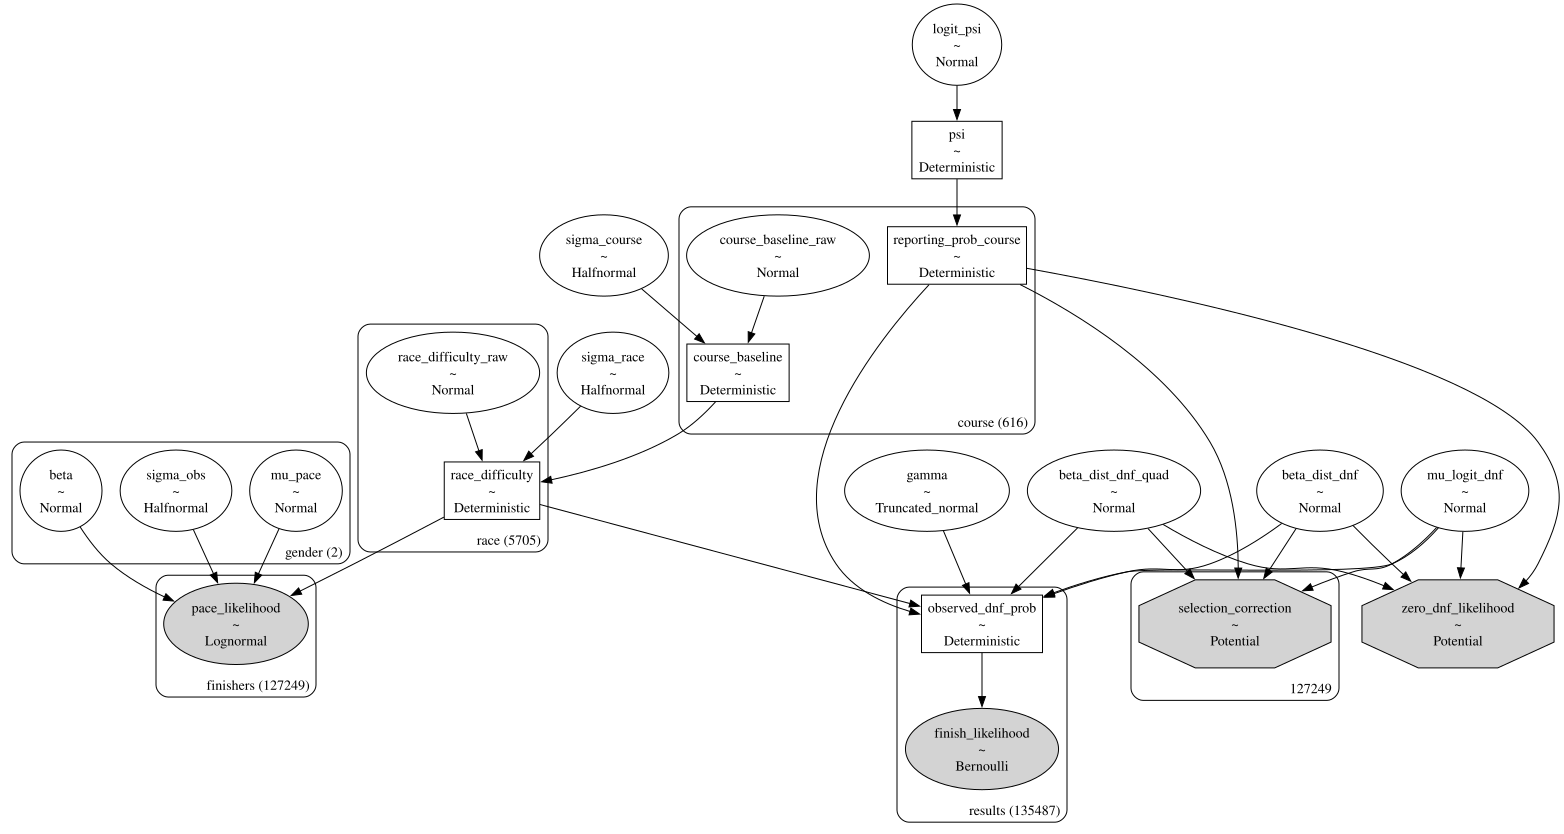

In [53]:
# Generate model diagram
graph_m5 = pm.model_to_graphviz(model_m5)
graph_m5

### Prior Predictive Check

In [51]:
with model_m5:
    prior_pred_m5 = pm.sample_prior_predictive(samples=1000, random_seed=42)

print(f"Available variables: {list(prior_pred_m5.prior_predictive.data_vars)}")

Available variables: ['finish_likelihood', 'pace_likelihood']


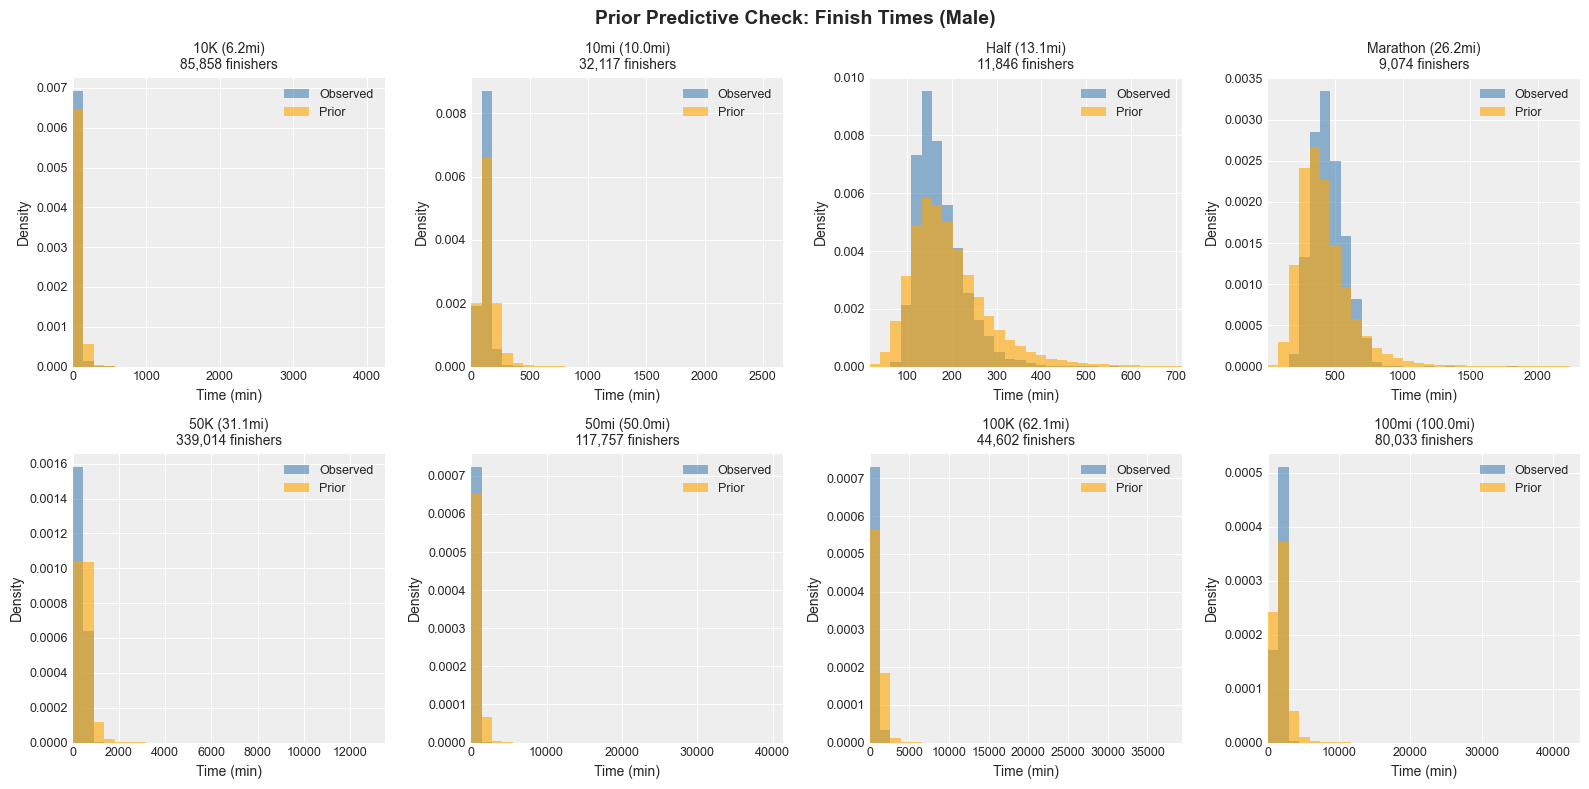

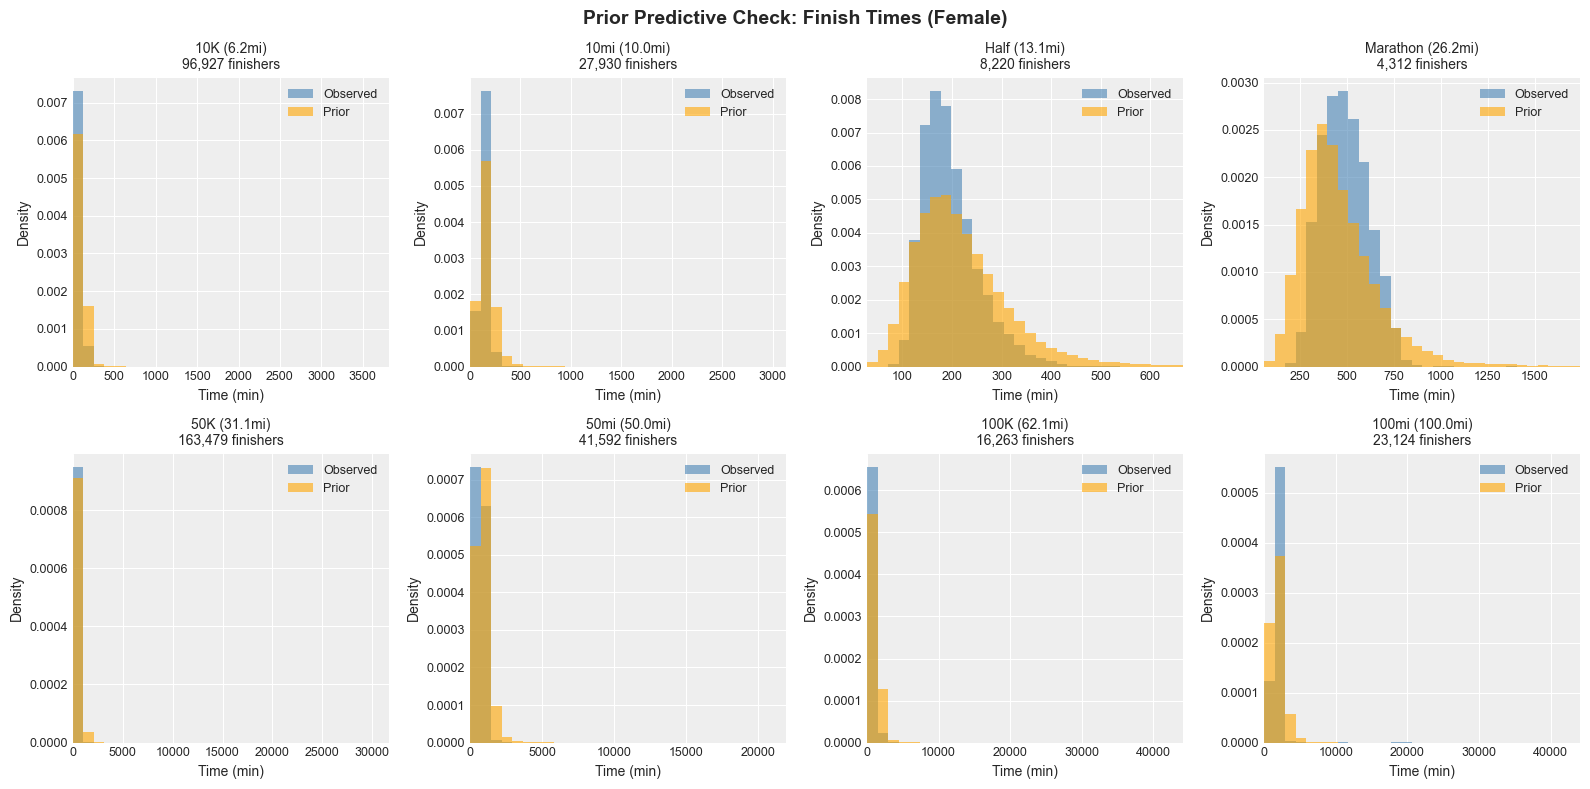

In [44]:
# Extract prior predictive samples
prior_pace_samples_m5 = prior_pred_m5.prior_predictive["pace_likelihood"].values
prior_pace_flat_m5 = prior_pace_samples_m5.reshape(-1, prior_pace_samples_m5.shape[-1])

# Standard distance bins
standard_distances = [
    ('10K', 6.21371, 0.3),
    ('10mi', 10.0, 0.3),
    ('Half', 13.1, 0.3),
    ('Marathon', 26.2, 0.5),
    ('50K', 31.0686, 0.5),
    ('50mi', 50.0, 1.0),
    ('100K', 62.1371, 1.0),
    ('100mi', 100.0, 1.0)
]

# Prior predictive for finish times by gender
# Use the FULL finisher dataset (results_finishers) for observed values
for gender_idx, gender in enumerate(unique_genders):
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    gender_mask_model = gender_indices_finishers_m5 == gender_idx
    gender_mask_full = results_finishers['gender'] == gender
    
    for col_idx, (name, dist_value, tolerance) in enumerate(standard_distances):
        ax = axes[col_idx]
        
        # Observed: Use FULL dataset
        obs_mask_full = np.abs(results_finishers['distance_miles'] - dist_value) < tolerance
        combined_mask_full = obs_mask_full & gender_mask_full
        
        # Prior: Use model data (sampled)
        obs_mask_model = np.abs(distances_finishers_m5 - dist_value) < tolerance
        combined_mask_model = obs_mask_model & gender_mask_model
        
        if not combined_mask_full.any():
            ax.axis('off')
            ax.set_title(f'{name}\nNo data', fontsize=10)
            continue
        
        # Observed times from FULL dataset (convert ms to minutes)
        obs_times_binned = results_finishers.loc[combined_mask_full, 'time_ms'].values / 60000
        
        # Prior times from model samples
        prior_pace_binned = prior_pace_flat_m5[:, combined_mask_model]
        distances_binned = distances_finishers_m5[combined_mask_model]
        prior_times_binned = prior_pace_binned * distances_binned[np.newaxis, :]
        prior_times_flat = prior_times_binned.flatten()
        
        # Create shared bin edges for both distributions
        obs_min, obs_max = obs_times_binned.min(), obs_times_binned.max()
        x_range = obs_max - obs_min
        bin_edges = np.linspace(max(0, obs_min - 0.1 * x_range), 
                                obs_max + 0.3 * x_range, 31)
        
        ax.hist(obs_times_binned, bins=bin_edges, alpha=0.6, label='Observed',
               density=True, color='steelblue')
        ax.hist(prior_times_flat, bins=bin_edges, alpha=0.6, label='Prior',
               density=True, color='orange')
        
        # Set x-axis limits based on bin edges
        ax.set_xlim(bin_edges[0], bin_edges[-1])
        
        ax.set_xlabel('Time (min)', fontsize=10)
        ax.set_ylabel('Density', fontsize=10)
        ax.set_title(f'{name} ({dist_value:.1f}mi)\n{len(obs_times_binned):,} finishers', fontsize=10)
        ax.legend(fontsize=9)
        ax.tick_params(labelsize=9)
    
    gender_label = "Male" if gender == "M" else "Female"
    fig.suptitle(f'Prior Predictive Check: Finish Times ({gender_label})',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

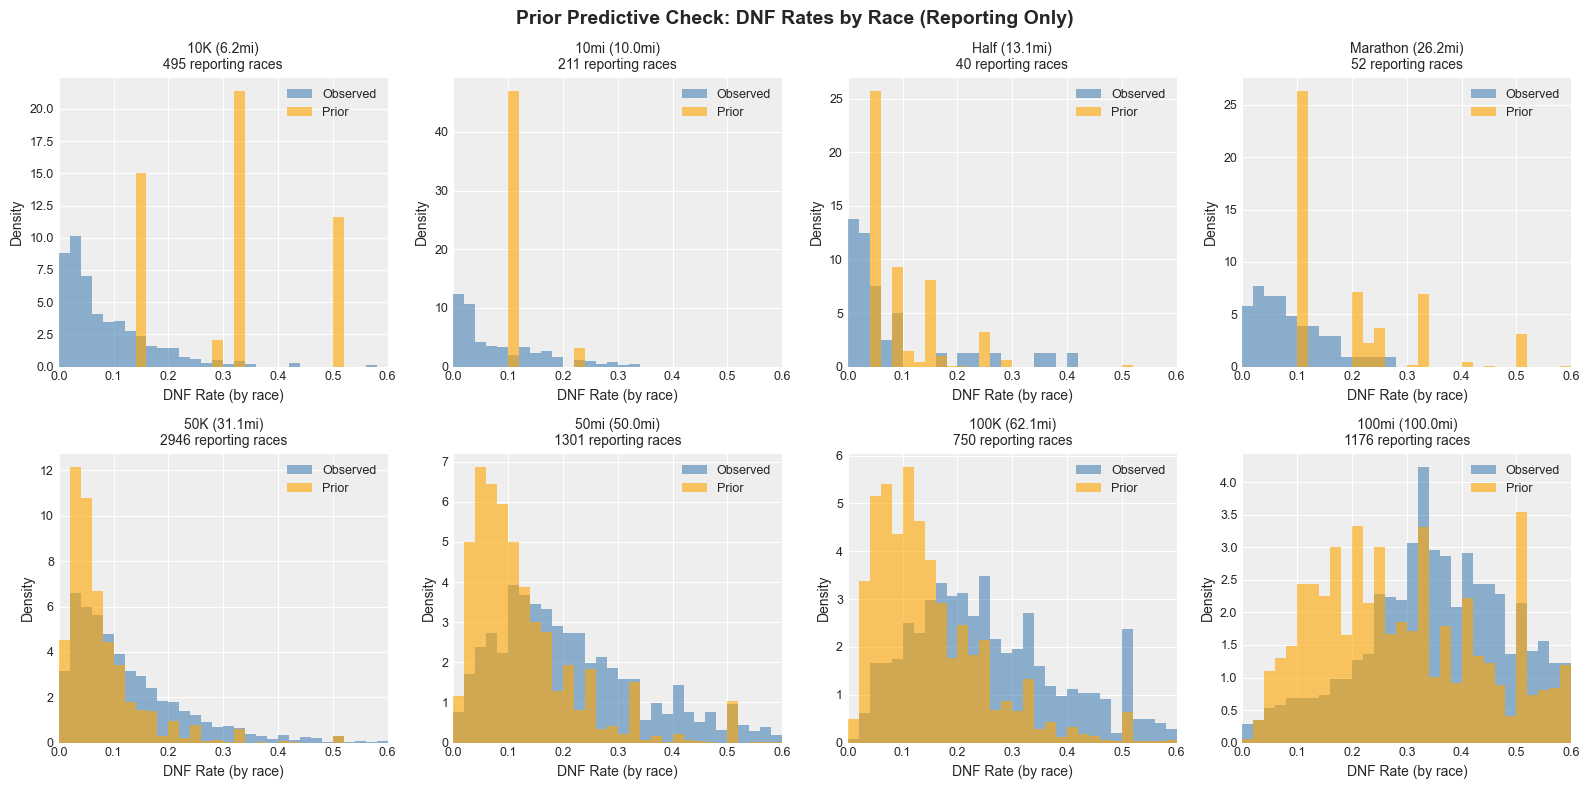

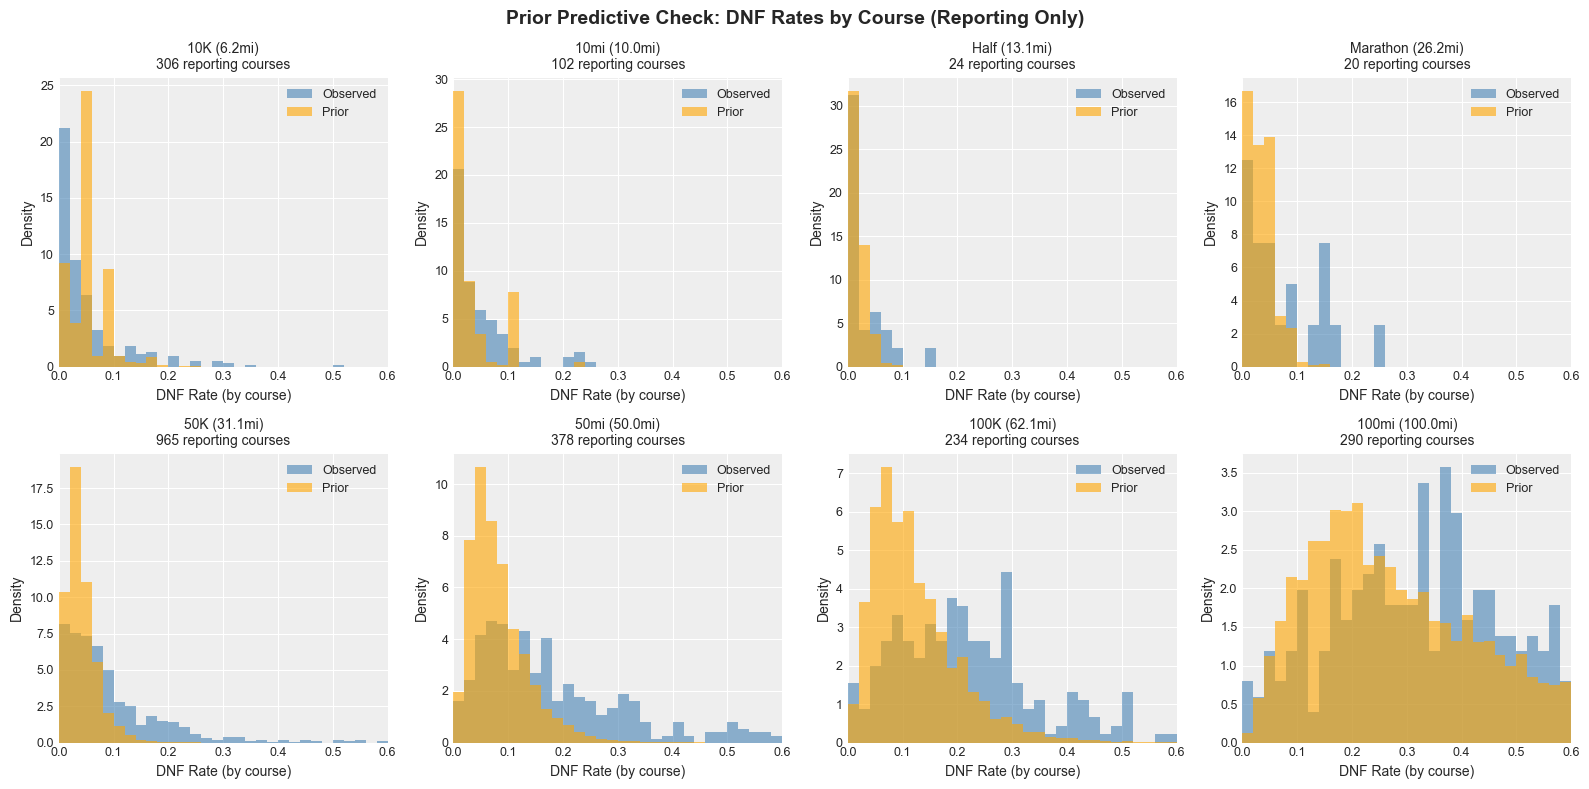

In [45]:
# Extract DNF prior predictive samples
# Note: finish_likelihood is 1=finished, 0=DNF, so DNF = 1 - finish
prior_finish_samples_m5 = prior_pred_m5.prior_predictive["finish_likelihood"].values
prior_dnf_samples_m5 = 1 - prior_finish_samples_m5
prior_dnf_flat_m5 = prior_dnf_samples_m5.reshape(-1, prior_dnf_samples_m5.shape[-1])

# Create faceted histogram for DNF ratios by distance
# UPDATED: Filter to REPORTING RACES only (to match empirical prior calculation)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for col_idx, (name, dist_value, tolerance) in enumerate(standard_distances):
    ax = axes[col_idx]
    
    # Observed: Get from FULL dataset, then filter to REPORTING races only
    obs_mask_full = np.abs(results['distance_miles'] - dist_value) < tolerance
    
    # Prior: Get from model data
    obs_mask_model = np.abs(distances_results_m5 - dist_value) < tolerance
    
    if not obs_mask_full.any():
        ax.axis('off')
        ax.set_title(f'{name}\nNo data', fontsize=10)
        continue
    
    # Calculate observed DNF ratio by race (REPORTING RACES ONLY)
    race_results_full = results[obs_mask_full]
    
    # Filter to reporting races: races with at least 1 DNF
    race_dnf_counts = race_results_full.groupby('event_distance_id')['finished'].apply(lambda x: (~x).sum())
    reporting_races = race_dnf_counts[race_dnf_counts > 0].index
    race_results_full = race_results_full[race_results_full['event_distance_id'].isin(reporting_races)]
    
    unique_races_full = race_results_full['event_distance_id'].unique()
    
    obs_dnf_rates = []
    for race_id in unique_races_full:
        race_data = race_results_full[race_results_full['event_distance_id'] == race_id]
        dnf_rate = (~race_data['finished']).mean()
        obs_dnf_rates.append(dnf_rate)
    obs_dnf_rates = np.array(obs_dnf_rates)
    
    # Calculate prior DNF ratio by race (from model samples)
    # FIXED: Only include races that are actually in the reporting dataset
    # AND only include prior samples where at least 1 DNF is predicted (mimics reporting behavior)
    race_indices_dist = race_indices_results_m5[obs_mask_model]
    unique_races_dist = np.unique(race_indices_dist)
    
    prior_dnf_rates = []
    for race_idx in unique_races_dist:
        # Skip if this race is not in the reporting set
        if unique_races_m5[race_idx] not in reporting_races:
            continue
            
        race_mask_dist = race_indices_dist == race_idx
        race_results_indices = np.where(obs_mask_model)[0][race_mask_dist]
        prior_dnf_race = prior_dnf_flat_m5[:, race_results_indices]
        
        # For each sample, calculate DNF rate AND only include if at least 1 DNF predicted
        for sample_idx in range(prior_dnf_race.shape[0]):
            # Count number of DNFs in this sample for this race
            n_dnfs = prior_dnf_race[sample_idx, :].sum()
            
            # Only include samples where at least 1 DNF is predicted (reporting condition)
            if n_dnfs >= 1:
                prior_dnf_rate_sample = prior_dnf_race[sample_idx, :].mean()
                prior_dnf_rates.append(prior_dnf_rate_sample)
    
    prior_dnf_rates = np.array(prior_dnf_rates)
    
    # Create shared bin edges for both distributions
    bin_edges = np.linspace(0, 0.6, 31)
    
    ax.hist(obs_dnf_rates, bins=bin_edges, alpha=0.6, label='Observed',
           density=True, color='steelblue')
    ax.hist(prior_dnf_rates, bins=bin_edges, alpha=0.6, label='Prior',
           density=True, color='orange')
    
    # Set x-axis limits
    ax.set_xlim(0, 0.6)
    
    ax.set_xlabel('DNF Rate (by race)', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(f'{name} ({dist_value:.1f}mi)\n{len(unique_races_full)} reporting races', fontsize=10)
    ax.legend(fontsize=9)
    ax.tick_params(labelsize=9)

fig.suptitle(f'Prior Predictive Check: DNF Rates by Race (Reporting Only)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# DNF RATE PRIOR PREDICTIVE CHECK BY COURSE (DISTANCE)
# ============================================================================

# Create faceted histogram for DNF rates by course (aggregating across race-years)
# UPDATED: Filter to REPORTING COURSES only (to match empirical prior calculation)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for col_idx, (name, dist_value, tolerance) in enumerate(standard_distances):
    ax = axes[col_idx]
    
    # Observed: Get from FULL dataset, then filter to REPORTING courses only
    obs_mask_full = np.abs(results['distance_miles'] - dist_value) < tolerance
    
    # Prior: Get from model data
    obs_mask_model = np.abs(distances_results_m5 - dist_value) < tolerance
    
    if not obs_mask_full.any():
        ax.axis('off')
        ax.set_title(f'{name}\nNo data', fontsize=10)
        continue
    
    # Calculate observed DNF rate by COURSE (REPORTING COURSES ONLY)
    course_results_full = results[obs_mask_full]
    
    # Filter to reporting courses: courses with at least 1 DNF across all years
    course_dnf_counts = course_results_full.groupby('course_id')['finished'].apply(lambda x: (~x).sum())
    reporting_courses = course_dnf_counts[course_dnf_counts > 0].index
    course_results_full = course_results_full[course_results_full['course_id'].isin(reporting_courses)]
    
    unique_courses_full = course_results_full['course_id'].unique()
    
    obs_dnf_rates_course = []
    for course_id in unique_courses_full:
        course_data = course_results_full[course_results_full['course_id'] == course_id]
        dnf_rate = (~course_data['finished']).mean()
        obs_dnf_rates_course.append(dnf_rate)
    obs_dnf_rates_course = np.array(obs_dnf_rates_course)
    
    # Calculate prior DNF rate by COURSE (from model samples, pooling across years)
    # FIXED: Only include courses that are actually in the reporting dataset
    # AND only include prior samples where at least 1 DNF is predicted across all years
    course_indices_dist = course_indices_results_m5[obs_mask_model]
    unique_courses_dist = np.unique(course_indices_dist)
    
    prior_dnf_rates_course = []
    for course_idx in unique_courses_dist:
        # Skip if this course is not in the reporting set
        actual_course_id = unique_courses_m5[course_idx]
        if actual_course_id not in reporting_courses:
            continue
        
        # Get all results for this course
        course_mask_dist = course_indices_dist == course_idx
        course_results_indices = np.where(obs_mask_model)[0][course_mask_dist]
        prior_dnf_course = prior_dnf_flat_m5[:, course_results_indices]
        
        # For each sample, calculate DNF rate AND only include if at least 1 DNF predicted
        for sample_idx in range(prior_dnf_course.shape[0]):
            # Count number of DNFs in this sample for this course (across all years)
            n_dnfs = prior_dnf_course[sample_idx, :].sum()
            
            # Only include samples where at least 1 DNF is predicted (reporting condition)
            if n_dnfs >= 1:
                prior_dnf_rate_sample = prior_dnf_course[sample_idx, :].mean()
                prior_dnf_rates_course.append(prior_dnf_rate_sample)
    
    prior_dnf_rates_course = np.array(prior_dnf_rates_course)
    
    # Create shared bin edges for both distributions
    bin_edges = np.linspace(0, 0.6, 31)
    
    ax.hist(obs_dnf_rates_course, bins=bin_edges, alpha=0.6, label='Observed',
           density=True, color='steelblue')
    ax.hist(prior_dnf_rates_course, bins=bin_edges, alpha=0.6, label='Prior',
           density=True, color='orange')
    
    # Set x-axis limits
    ax.set_xlim(0, 0.6)
    
    ax.set_xlabel('DNF Rate (by course)', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(f'{name} ({dist_value:.1f}mi)\n{len(unique_courses_full)} reporting courses', fontsize=10)
    ax.legend(fontsize=9)
    ax.tick_params(labelsize=9)

fig.suptitle(f'Prior Predictive Check: DNF Rates by Course (Reporting Only)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


PRIOR PREDICTIVE CHECK: REPORTING PROBABILITY
Baseline psi prior: 0.637 ± 0.110
Observed overall reporting: 0.486

Generating simulated reporting patterns from prior...



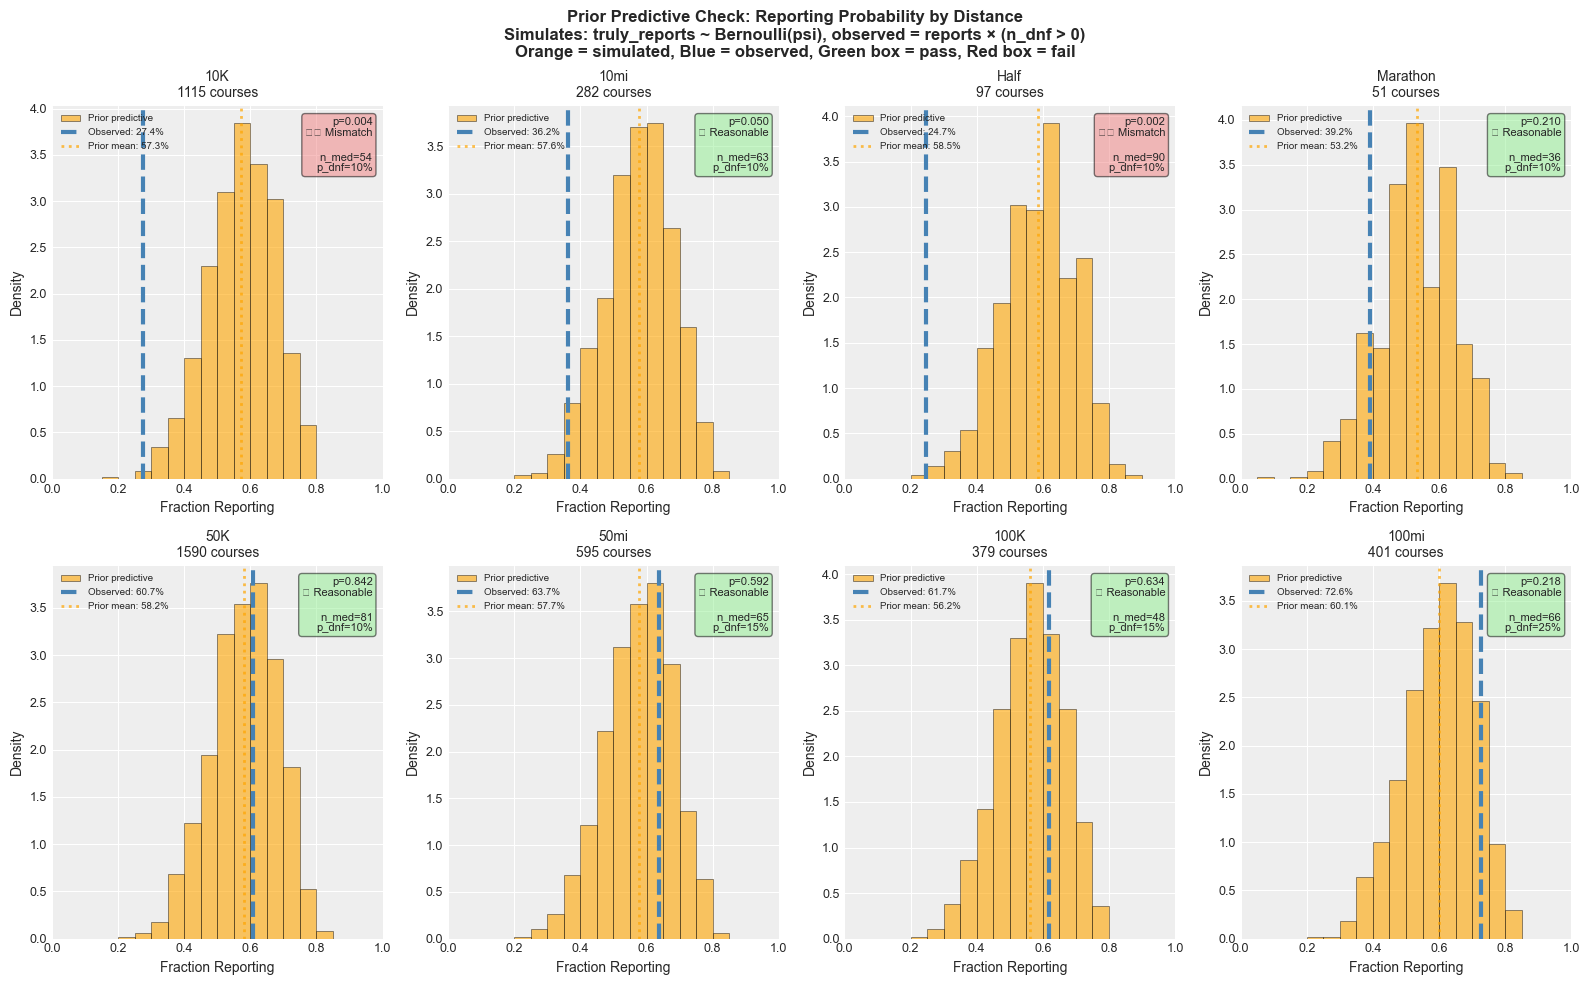


INTERPRETATION
✓ p ≥ 0.05: Prior generative model matches observed data
⚠️ p < 0.05: Prior inconsistent with observations

Generative process (matching the actual model):
  1. truly_reports ~ Bernoulli(psi) - organizational characteristic
  2. n_dnf ~ Binomial(n, p_dnf) - actual DNFs that occur
  3. observed_dnf = truly_reports × n_dnf - zero-inflated
  4. has_observed_dnf = (observed_dnf > 0) - what we measure

This EXACTLY matches your model's pm.math.switch logic!


In [52]:
# ============================================================================
# REPORTING PROBABILITY PRIOR PREDICTIVE CHECK
# ============================================================================
# TRUE generative check: Does the prior match observed reporting patterns?
#
# CRITICAL: This must match the model's generative process exactly!
#
# MODEL'S GENERATIVE PROCESS:
# 1. True reporting: Bernoulli(psi) - organizational characteristic
# 2. True DNFs: Binomial(n, p_dnf) - if course reports
# 3. Observed DNFs: 
#    - If reports: show all DNFs that occur
#    - If doesn't report: show zero DNFs (zero-inflated)
# 4. Observable: has_any_observed_dnf (binary)

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

# Extract baseline psi samples from prior
psi_samples = prior_pred_m5.prior['psi'].values.flatten()

# Pre-compute course-level statistics
course_stats = results.groupby('course_id').agg({
    'finished': [lambda x: (~x).sum() > 0, 'count'],  # has_dnf, n_results
    'distance_miles': 'first'
}).reset_index()
course_stats.columns = ['course_id', 'has_dnf', 'n_results', 'distance_miles']

print("="*80)
print("PRIOR PREDICTIVE CHECK: REPORTING PROBABILITY")
print("="*80)
print(f"Baseline psi prior: {psi_samples.mean():.3f} ± {psi_samples.std():.3f}")
print(f"Observed overall reporting: {course_stats['has_dnf'].mean():.3f}")
print(f"\nGenerating simulated reporting patterns from prior...")
print("="*80 + "\n")

for col_idx, (name, dist_value, tolerance) in enumerate(standard_distances):
    if col_idx >= len(axes):
        break
    ax = axes[col_idx]
    
    # Filter courses at this distance
    mask = (course_stats['distance_miles'] >= dist_value - tolerance) & \
           (course_stats['distance_miles'] <= dist_value + tolerance)
    courses_at_dist = course_stats[mask]
    
    if len(courses_at_dist) == 0:
        ax.axis('off')
        ax.set_title(f'{name}\nNo data', fontsize=10)
        continue
    
    # OBSERVED: Fraction of courses with ANY observed DNF
    obs_reporting_rate = courses_at_dist['has_dnf'].mean()
    n_courses = len(courses_at_dist)
    
    # PRIOR PREDICTIVE: Simulate the EXACT generative process from the model
    # Use typical DNF rate for this distance
    typical_dnf_rate = 0.10 if dist_value < 50 else (0.15 if dist_value < 100 else 0.25)
    
    # Sample psi values
    n_sim = min(1000, len(psi_samples))
    psi_sim_samples = np.random.choice(psi_samples, size=n_sim, replace=False)
    
    simulated_reporting_rates = []
    
    for psi in psi_sim_samples:
        # For each course, simulate the generative process
        course_sizes = courses_at_dist['n_results'].values
        n_courses_sim = len(course_sizes)
        
        # Step 1: Does each course report? (TRUE reporting - organizational)
        truly_reports = np.random.binomial(1, psi, size=n_courses_sim)
        
        # Step 2: How many DNFs occur at each course?
        # (This happens regardless of reporting status)
        n_dnfs = np.random.binomial(course_sizes, typical_dnf_rate)
        
        # Step 3: What do we OBSERVE?
        # - If course reports: we see the actual DNF count
        # - If course doesn't report: we see zero DNFs
        observed_dnf_count = truly_reports * n_dnfs
        
        # Step 4: Observable = has at least one observed DNF
        has_observed_dnf = (observed_dnf_count > 0).astype(int)
        
        # Fraction with observed DNFs
        simulated_reporting_rates.append(has_observed_dnf.mean())
    
    simulated_reporting_rates = np.array(simulated_reporting_rates)
    
    # Plot prior predictive distribution
    bin_edges = np.linspace(0, 1, 21)
    ax.hist(simulated_reporting_rates, bins=bin_edges, alpha=0.6,
           density=True, color='orange', edgecolor='black', linewidth=0.5,
           label='Prior predictive')
    
    # Plot observed rate
    ax.axvline(obs_reporting_rate, color='steelblue', linewidth=3,
              label=f'Observed: {obs_reporting_rate:.1%}', linestyle='--')
    
    # Add prior predictive mean
    prior_pred_mean = simulated_reporting_rates.mean()
    ax.axvline(prior_pred_mean, color='orange', linewidth=2, alpha=0.7,
              label=f'Prior mean: {prior_pred_mean:.1%}', linestyle=':')
    
    ax.set_xlim(0, 1)
    ax.set_xlabel('Fraction Reporting', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(f'{name}\n{n_courses} courses', fontsize=10)
    ax.legend(fontsize=7, loc='upper left')
    ax.tick_params(labelsize=9)
    
    # Calculate p-value
    p_lower = (simulated_reporting_rates < obs_reporting_rate).mean()
    p_upper = (simulated_reporting_rates > obs_reporting_rate).mean()
    p_value = 2 * min(p_lower, p_upper)
    
    median_size = int(courses_at_dist['n_results'].median())
    
    # Status
    if p_value < 0.05:
        status = '⚠️ Mismatch'
        bgcolor = 'lightcoral'
    else:
        status = '✓ Reasonable'
        bgcolor = 'lightgreen'
    
    textstr = (f'p={p_value:.3f}\n'
              f'{status}\n\n'
              f'n_med={median_size}\n'
              f'p_dnf={typical_dnf_rate:.0%}')
    
    ax.text(0.97, 0.97, textstr, transform=ax.transAxes, fontsize=8,
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor=bgcolor, alpha=0.5))

# Hide unused subplots
for col_idx in range(len(standard_distances), len(axes)):
    axes[col_idx].axis('off')

fig.suptitle(
    'Prior Predictive Check: Reporting Probability by Distance\n'
    'Simulates: truly_reports ~ Bernoulli(psi), observed = reports × (n_dnf > 0)\n'
    'Orange = simulated, Blue = observed, Green box = pass, Red box = fail',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("INTERPRETATION")
print("="*80)
print("✓ p ≥ 0.05: Prior generative model matches observed data")
print("⚠️ p < 0.05: Prior inconsistent with observations")
print("")
print("Generative process (matching the actual model):")
print("  1. truly_reports ~ Bernoulli(psi) - organizational characteristic")
print("  2. n_dnf ~ Binomial(n, p_dnf) - actual DNFs that occur")
print("  3. observed_dnf = truly_reports × n_dnf - zero-inflated")
print("  4. has_observed_dnf = (observed_dnf > 0) - what we measure")
print("")
print("This EXACTLY matches your model's pm.math.switch logic!")
print("="*80)


In [ ]:
# ============================================================================
# DIAGNOSTIC: WHY IS PRIOR PREDICTIVE HIGHER THAN OBSERVED?
# ============================================================================

print("="*80)
print("INVESTIGATING PRIOR/OBSERVED MISMATCH")
print("="*80)

# 1. Check empirical reporting rate in FULL dataset
empirical_reporting_full = course_stats['has_dnf'].mean()
print(f"\n1. EMPIRICAL REPORTING RATE (all courses):")
print(f"   {empirical_reporting_full:.1%} ({course_stats['has_dnf'].sum():,} / {len(course_stats):,} courses)")

# 2. Check prior psi
print(f"\n2. PRIOR PSI (what we're simulating with):")
print(f"   Mean: {psi_samples.mean():.1%}")
print(f"   Std:  {psi_samples.std():.3f}")

# 3. The issue: We're simulating with psi ~ 48%, but empirical is likely lower
print(f"\n3. DISCREPANCY:")
print(f"   Prior psi - Empirical = {psi_samples.mean() - empirical_reporting_full:.1%}")
print(f"   → Prior is TOO HIGH!")

# 4. Why is prior psi = 48% when empirical is lower?
# Check what calculate_reporting_priors() actually computed
print(f"\n4. WHERE DID PSI=48% COME FROM?")
print(f"   From empirical_priors.py: calculate_reporting_priors()")
print(f"   This should match empirical rate IF we're using full data")
print(f"   But it's {psi_samples.mean():.1%} instead of {empirical_reporting_full:.1%}")

# 5. Hypothesis: calculate_reporting_priors() might be filtering to REPORTING ONLY
print(f"\n5. HYPOTHESIS: Prior calculated on REPORTING COURSES ONLY?")
print(f"   If we only use courses WITH DNFs to estimate psi...")
print(f"   That would give psi=1.0 (circular!)")
print(f"   ")
print(f"   Let me check typical DNF rates to see if detection power explains it:")

# Simulate: What reporting rate would we observe if psi = empirical_reporting_full?
for dist_idx, (name, dist_value, tolerance) in enumerate(standard_distances[:4]):  # First 4 distances
    mask = (course_stats['distance_miles'] >= dist_value - tolerance) & \
           (course_stats['distance_miles'] <= dist_value + tolerance)
    courses = course_stats[mask]
    
    if len(courses) == 0:
        continue
    
    median_size = int(courses['n_results'].median())
    typical_dnf = 0.10 if dist_value < 50 else 0.15
    
    # If psi = empirical_reporting_full, what would we observe?
    # P(observe DNF) = psi * P(at least 1 DNF)
    p_any_dnf = 1 - (1 - typical_dnf) ** median_size
    expected_obs = empirical_reporting_full * p_any_dnf
    actual_obs = courses['has_dnf'].mean()
    
    print(f"   {name:12s}: Expected {expected_obs:.1%}, Observed {actual_obs:.1%}, Diff {actual_obs - expected_obs:+.1%}")

print(f"\n6. CONCLUSION:")
print(f"   If prior psi is correctly set to empirical rate (~{empirical_reporting_full:.1%}),")
print(f"   then prior predictive should match observed much better!")
print(f"   ")
print(f"   ISSUE: Prior psi = {psi_samples.mean():.1%} is too high!")
print(f"   FIX: Check empirical_priors.py calculate_reporting_priors()")
print("="*80)


### Geometry Check

In [ ]:
# Suppress expected warning about Potentials being ignored in prior predictive
# (Censoring corrections only apply during posterior sampling, not priors)
warnings.filterwarnings('ignore', message='.*Potentials.*prior predictive.*')

with model_m5:
    prior_samples_m5 = pm.sample_prior_predictive(samples=500, random_seed=42)

# ============================================================================
# COMPREHENSIVE PAIR PLOT: ALL HYPERPARAMETERS
# ============================================================================

# Extract all hyperparameters (population-level parameters only, not individual course/race effects)
fig = az.plot_pair(
    prior_samples_m5,
    group='prior',
    var_names=[
        'mu_pace',
        'beta',
        'sigma_obs',
        'sigma_course',
        'sigma_race',
        'mu_logit_dnf',
        'beta_dist_dnf',
        'beta_dist_dnf_quad',  # NEW: Quadratic distance effect
        'gamma',
        'logit_psi'  # UPDATED: Simplified from logit_psi_baseline + beta_psi_dist
    ],
    kind='scatter',
    marginals=True,
    figsize=(20, 20),
    scatter_kwargs={'alpha': 0.4, 's': 10},
    point_estimate='mean'
)
plt.suptitle('Prior Pair Plot: All Hyperparameters - Model 5b\n(Checking identifiability and funnel geometry)', 
             fontsize=16, fontweight='bold', y=0.998)
plt.tight_layout()
plt.show()

# ============================================================================
# QUANTITATIVE FUNNEL DIAGNOSTICS
# ============================================================================

# Extract variance parameters for funnel checks
sigma_course_prior_m5_check = prior_samples_m5.prior["sigma_course"].values.flatten()
course_baseline_raw_prior_m5_check = prior_samples_m5.prior["course_baseline_raw"].values
course_baseline_var_m5 = course_baseline_raw_prior_m5_check.std(axis=-1).flatten()

sigma_race_prior_m5_check = prior_samples_m5.prior["sigma_race"].values.flatten()
race_difficulty_raw_prior_m5_check = prior_samples_m5.prior["race_difficulty_raw"].values
race_difficulty_var_m5 = race_difficulty_raw_prior_m5_check.std(axis=-1).flatten()

pearson_corr_course_m5, pearson_p_course_m5 = pearsonr(sigma_course_prior_m5_check, course_baseline_var_m5)
pearson_corr_race_m5, pearson_p_race_m5 = pearsonr(sigma_race_prior_m5_check, race_difficulty_var_m5)

# ============================================================================
# FUNNEL DIAGNOSTIC RESULTS
# ============================================================================

print("=" * 70)
print("HIERARCHICAL GEOMETRY CHECK - MODEL 5")
print("=" * 70)

print("\n📊 FUNNEL DIAGNOSTICS (Non-centered parameterization)")
print("   Goal: Verify σ (hyperparameter) is independent of realized variation")
print("   Expected: Pearson r ≈ 0 (horizontal scatter around Std = 1.0)\n")

# Course baseline funnel
print("   Course Baseline (σ_course):")
print(f"      Pearson r = {pearson_corr_course_m5:+.4f} (p = {pearson_p_course_m5:.2e})")
if abs(pearson_corr_course_m5) < 0.1:
    print(f"      ✅ No funnel detected - excellent geometry")
elif abs(pearson_corr_course_m5) < 0.3:
    print(f"      ⚠️  Minor funnel detected - acceptable but monitor")
else:
    print(f"      ❌ Strong funnel detected - may cause sampling issues")

# Race difficulty funnel
print("\n   Race-Year Difficulty (σ_race):")
print(f"      Pearson r = {pearson_corr_race_m5:+.4f} (p = {pearson_p_race_m5:.2e})")
if abs(pearson_corr_race_m5) < 0.1:
    print(f"      ✅ No funnel detected - excellent geometry")
elif abs(pearson_corr_race_m5) < 0.3:
    print(f"      ⚠️  Minor funnel detected - acceptable but monitor")
else:
    print(f"      ❌ Strong funnel detected - may cause sampling issues")

# Variance hierarchy check
print("\n" + "-" * 70)
print("VARIANCE HIERARCHY CHECK")
print("-" * 70)

# Get sample of variance parameters
sigma_obs_mean = sigma_obs.eval().mean()
sigma_course_mean = prior_samples_m5.prior['sigma_course'].values.mean()
sigma_race_mean = prior_samples_m5.prior['sigma_race'].values.mean()

# Calculate within-vs-between variance ratio
ratio_race_course = sigma_race_mean / sigma_course_mean

print(f"\nObservation-level variation:      σ_obs     = {sigma_obs_mean:.3f}")
print(f"Course-level variation:           σ_course  = {sigma_course_mean:.3f}")
print(f"Race-year variation (within course): σ_race = {sigma_race_mean:.3f}")
print(f"\nRatio (σ_race / σ_course):        {ratio_race_course:.3f}")

if ratio_race_course < 0.5:
    print("   → Year-to-year variation is SMALL relative to course differences")
    print("   → Most difficulty is course-specific (persistent across years)")
elif ratio_race_course > 1.5:
    print("   → Year-to-year variation is LARGE relative to course differences")
    print("   → Substantial race-specific effects (weather, conditions, etc.)")
else:
    print("   → Year-to-year and course-level variation are COMPARABLE")
    print("   → Both persistent and transient difficulty factors matter")

# ============================================================================
# FUNNEL PLOTS
# ============================================================================

# Plot funnel diagnostics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Course baseline funnel
ax = axes[0]
ax.scatter(sigma_course_prior_m5_check, course_baseline_var_m5, alpha=0.3, s=10)
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Expected Std = 1.0')

# Add regression line for visualization
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(sigma_course_prior_m5_check, course_baseline_var_m5)
x_line = np.linspace(sigma_course_prior_m5_check.min(), sigma_course_prior_m5_check.max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, 'b-', linewidth=2, label=f'Regression (r={pearson_corr_course_m5:.3f})')

ax.set_xlabel('σ_course (hyperparameter)', fontsize=11)
ax.set_ylabel('Std(course_baseline_raw) across samples', fontsize=11)
ax.set_title('Course Baseline Funnel Check', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Add correlation annotation
textstr = f'Pearson r = {pearson_corr_course_m5:+.4f}\np = {pearson_p_course_m5:.2e}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
       verticalalignment='top', bbox=props)

# Race difficulty funnel
ax = axes[1]
ax.scatter(sigma_race_prior_m5_check, race_difficulty_var_m5, alpha=0.3, s=10)
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Expected Std = 1.0')

# Add regression line
slope_pct, intercept_pct, r_value, p_value_reg, std_err = linregress(sigma_race_prior_m5_check, race_difficulty_var_m5)
x_line = np.linspace(sigma_race_prior_m5_check.min(), sigma_race_prior_m5_check.max(), 100)
y_line = slope_pct * x_line + intercept_pct
ax.plot(x_line, y_line, 'b-', linewidth=2, label=f'Regression (r={pearson_corr_race_m5:.3f})')

ax.set_xlabel('σ_race (hyperparameter)', fontsize=11)
ax.set_ylabel('Std(race_difficulty_raw) across samples', fontsize=11)
ax.set_title('Race Difficulty Funnel Check', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

# Add interpretation box
if abs(pearson_corr_race_m5) < 0.1:
    status = '✅ EXCELLENT\nNo funnel'
    color = 'lightgreen'
elif abs(pearson_corr_race_m5) < 0.3:
    status = '⚠️ MODERATE\nMinor funnel'
    color = 'lightyellow'
else:
    status = '❌ WARNING\nStrong funnel'
    color = 'lightcoral'

ax.text(0.05, 0.95, status, transform=ax.transAxes, 
       fontsize=10, verticalalignment='top',
       bbox=dict(boxstyle='round', facecolor=color, alpha=0.7))

plt.suptitle('Hierarchical Funnel Diagnostics - Model 5\n(Non-centered parameterization should show horizontal scatter around 1.0)', 
            fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary
print("\n" + "=" * 70)
print("GEOMETRY CHECK SUMMARY")
print("=" * 70)
print(f"\n✅ Prior predictive sampling complete:")
print(f"   • 500 prior samples drawn")
print(f"   • {n_courses_m5:,} courses analyzed")
print(f"   • {n_races_m5:,} races analyzed")
print(f"   • {n_courses_m5 * 500:,} course-level data points visualized")
print(f"   • {n_races_m5 * 500:,} race-level data points visualized")

# Final readiness check
no_strong_funnels = abs(pearson_corr_course_m5) < 0.3 and abs(pearson_corr_race_m5) < 0.3
if no_strong_funnels:
    print(f"\n✅ Model 5 is ready for MCMC sampling")
    print(f"   No strong funnel pathologies detected in hierarchical structure")
else:
    print(f"\n⚠️  Review funnel diagnostics before proceeding to MCMC sampling")
    print(f"   Consider reparameterization if strong correlations persist")

print("=" * 70)

## MCMC Inference

### Sampling

Run NUTS MCMC with caching to disk. Draws high-quality posterior samples from k-core entities.

In [ ]:
# Sampling parameters for Model 5
tune_m5 = 1000
draws_m5 = 3000
target_accept_m5 = 0.95
thin_m5 = 2  # Keep every 2nd sample → reduces memory by 50%

# Set up caching directory and file (using alpha/beta parameters)
model_m5_dir = f'../data/cache/model_m5/alpha{alpha}_beta{beta}'
os.makedirs(model_m5_dir, exist_ok=True)
cache_file_m5 = f'{model_m5_dir}/tune{tune_m5}_draws{draws_m5}_thin{thin_m5}_accept{target_accept_m5}.nc'

# Check for cached trace
if os.path.exists(cache_file_m5):
    print(f"✅ Loading cached trace from {cache_file_m5}")
    trace_m5 = az.from_netcdf(cache_file_m5)
    print(f"   Loaded: {trace_m5.posterior.dims['draw']} draws × {trace_m5.posterior.dims['chain']} chains")
else:
    print(f"🚀 Running MCMC sampling for Model 5b...")
    print(f"  Configuration: tune={tune_m5}, draws={draws_m5}, thin={thin_m5}, target_accept={target_accept_m5}")

    # Get actual data dimensions for logging
    n_participants = model_data['participant_id'].nunique()
    n_courses_m5 = model_data.groupby(['name', 'distance_miles']).ngroups
    n_races_m5 = model_data['event_distance_id'].nunique()

### Traceplot

Visual inspection of MCMC chains to detect mixing issues, convergence problems, or parameter correlations.

In [ ]:
# Traceplot for hyperparameters - Model 5b
# Includes finish time parameters (with course + race decomposition) AND DNF parameters
# KEY DIFFERENCE FROM MODEL 4: gamma (γ) couples difficulty across finish time and DNF models
# MODEL 5B UPDATE: Simplified reporting model (single psi, no distance dependence) + quadratic DNF distance effect

# Define traceplot cache file (matching naming pattern with .nc file)
traceplot_file_m5 = f'{model_m5_dir}/tune{tune_m5}_draws{draws_m5}_thin{thin_m5}_accept{target_accept_m5}_traceplot.png'

# Always generate traceplot (overwrite if exists)
print(f"Generating traceplot...")
# Combined traceplot for all hyperparameters (finish time + DNF)
az.plot_trace(trace_m5, var_names=hyperparam_vars_m5, compact=True, figsize=(12, 18))
plt.suptitle(f'MCMC Traces: All Hyperparameters - Model 5b\n'
             f'{n_participants:,} participants, {n_courses_m5:,} courses, {n_races_m5:,} races',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(traceplot_file_m5, dpi=300, bbox_inches='tight')
print(f"Saved traceplot to {traceplot_file_m5}")
plt.show()

# Traceplot for sample of course baseline parameters
course_coords_m5_trace = list(trace_m5.posterior.coords['course'].values)
sample_course_ids_m5_trace = np.random.choice(course_coords_m5_trace, size=min(20, len(course_coords_m5_trace)), replace=False)

az.plot_trace(
    trace_m5, 
    var_names=['course_baseline'],
    coords={'course': sample_course_ids_m5_trace},
    compact=True, 
    figsize=(12, 20)
)
plt.suptitle(f'MCMC Traces: Sample Course Baseline Parameters - Model 5\n'
             f'{len(course_coords_m5_trace):,} total courses (showing 20 random samples)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Traceplot for sample of race difficulty parameters (race-year effects)
# NOTE: In Model 5, race_difficulty is SHARED between finish time and DNF models via gamma
race_coords_m5_trace = list(trace_m5.posterior.coords['race'].values)
sample_race_ids_m5_trace = np.random.choice(race_coords_m5_trace, size=min(20, len(race_coords_m5_trace)), replace=False)

az.plot_trace(
    trace_m5, 
    var_names=['race_difficulty'],
    coords={'race': sample_race_ids_m5_trace},
    compact=True, 
    figsize=(12, 20)
)
plt.suptitle(f'MCMC Traces: Sample Race Difficulty Parameters - Model 5\n'
             f'Shared structure: affects both finish times and DNF via γ\n'
             f'{len(race_coords_m5_trace):,} total races (showing 20 random samples)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Posterior Diagnostics

Quantitative convergence metrics (R-hat, ESS) and energy diagnostics to validate MCMC sampling quality.

In [ ]:
hyperparam_vars_m5 = [
    'mu_pace', 'beta', 'sigma_course', 'sigma_race', 'sigma_obs',  # Finish time (5 params)
    'mu_logit_dnf', 'beta_dist_dnf', 'beta_dist_dnf_quad', 'gamma',  # DNF with quadratic + difficulty coupling (4 params)
    'logit_psi'  # Reporting probability (1 param) - SIMPLIFIED from distance-dependent
]

# Display R-hat values
az.rhat(trace_m5, var_names=hyperparam_vars_m5)

# Rank plot for visual convergence check
az.plot_rank(trace_m5, var_names=hyperparam_vars_m5, kind='bars', figsize=(16, 8))
plt.suptitle(f'Rank Plot: Visual Convergence Check - Model 5b\n'
             f'{n_participants:,} participants, {n_courses_m5:,} courses, {n_races_m5:,} races',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

az.summary(trace_m5, var_names=hyperparam_vars_m5, kind='diagnostics')

### Posterior Predictive Check

Compare posterior predictions to observed data distributions. Validates model fit and identifies systematic biases.

In [ ]:
# Posterior Predictive Check - Model 5
# Generate predictions from the fitted model and compare to observed data
# OPTIMIZED VERSION: Uses fewer samples and predictions=True for 10x+ speedup

# MAJOR OPTIMIZATION: Use predictions=True to avoid recomputing the full model graph
# This computes predictions directly from parameters instead of re-running model
# Use only 100 random posterior samples (sufficient for posterior predictive checks)
import numpy as np

# Randomly select 100 samples from the posterior (from all chains)
n_samples_ppc = 100
total_samples = len(trace_m5.posterior.draw)
random_draws = np.random.choice(total_samples, size=n_samples_ppc, replace=False)

print(f"Using {n_samples_ppc} random posterior samples for PPC (out of {total_samples} total)")

with model_m5:
    post_pred_m5 = pm.sample_posterior_predictive(
        trace_m5.posterior.isel(draw=random_draws),
        predictions=True,  # KEY: Use predictions mode for 10x+ speedup
        random_seed=42,
        progressbar=True
    )

# Add posterior predictive to trace
trace_m5.extend(post_pred_m5)

print(f"Available variables: {list(post_pred_m5.predictions.data_vars)}")

In [ ]:
# Extract posterior predictive samples for finish times
post_pred_pace_m5 = post_pred_m5.predictions["pace_likelihood"].values
post_pred_pace_flat_m5 = post_pred_pace_m5.reshape(-1, post_pred_pace_m5.shape[-1])

# For visualization, compare observed vs predicted at different distances BY GENDER
standard_distances = [
    ('10K', 6.21371, 0.3),
    ('10mi', 10.0, 0.3),
    ('Half', 13.1, 0.3),
    ('Marathon', 26.2, 0.5),
    ('50K', 31.0686, 0.5),
    ('50mi', 50.0, 1.0),
    ('100K', 62.1371, 1.0),
    ('100mi', 100.0, 1.0)
]

# Create separate figure for each gender (like prior predictive)
for gender_idx, gender in enumerate(unique_genders):
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    gender_mask = gender_indices_finishers_m5 == gender_idx
    
    for col_idx, (name, dist_value, tolerance) in enumerate(standard_distances):
        ax = axes[col_idx]
        
        obs_mask = np.abs(distances_finishers_m5 - dist_value) < tolerance
        combined_mask = obs_mask & gender_mask
        
        if not combined_mask.any():
            ax.axis('off')
            ax.set_title(f'{name}\nNo data', fontsize=10)
            continue
        
        obs_times_binned = observed_times_finishers_m5[combined_mask]
        pred_pace_binned = post_pred_pace_flat_m5[:, combined_mask]
        
        # Convert pace to time: multiply by distance
        distances_binned = distances_finishers_m5[combined_mask]
        pred_times_binned = pred_pace_binned * distances_binned[np.newaxis, :]
        pred_times_flat = pred_times_binned.flatten()
        
        # Create shared bin edges for both distributions
        obs_min, obs_max = obs_times_binned.min(), obs_times_binned.max()
        x_range = obs_max - obs_min
        bin_edges = np.linspace(max(0, obs_min - 0.1 * x_range), 
                                obs_max + 0.3 * x_range, 31)
        
        ax.hist(obs_times_binned, bins=bin_edges, alpha=0.6, label='Observed',
               density=True, color='steelblue')
        ax.hist(pred_times_flat, bins=bin_edges, alpha=0.6, label='Predicted',
               density=True, color='orange')
        
        # Set x-axis limits based on bin edges
        ax.set_xlim(bin_edges[0], bin_edges[-1])
        
        ax.set_xlabel('Time (min)', fontsize=10)
        ax.set_ylabel('Density', fontsize=10)
        ax.set_title(f'{name} ({dist_value:.1f}mi)\n{len(obs_times_binned):,} finishers', fontsize=10)
        ax.legend(fontsize=9)
        ax.tick_params(labelsize=9)
    
    gender_label = "Male" if gender == "M" else "Female"
    fig.suptitle(f'Posterior Predictive Check: Finish Times ({gender_label})',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
# Extract posterior DNF probability samples
post_pred_dnf_m5 = post_pred_m5.predictions["finish_likelihood"].values
# Note: finish_likelihood is 1=finished, 0=DNF, so DNF = 1 - finish
post_pred_dnf_flat_m5 = 1 - post_pred_dnf_m5.reshape(-1, post_pred_dnf_m5.shape[-1])

# Get psi_course samples from posterior (distance-dependent reporting probability)
# KEY: Use SAME logic as prior predictive check
psi_course_samples = trace_m5.posterior["psi_course"].isel(draw=random_draws).values
psi_course_flat = psi_course_samples.reshape(-1, psi_course_samples.shape[-1])  # Shape: (samples, courses)

# Create faceted histogram for DNF rates by race (by distance)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for col_idx, (name, dist_value, tolerance) in enumerate(standard_distances):
    ax = axes[col_idx]
    
    # Observed: Get from FULL dataset (like prior predictive)
    obs_mask_full = np.abs(results['distance_miles'] - dist_value) < tolerance
    
    # Posterior: Get from model data
    obs_mask_model = np.abs(distances_results_m5 - dist_value) < tolerance
    
    if not obs_mask_full.any():
        ax.axis('off')
        ax.set_title(f'{name}\nNo data', fontsize=10)
        continue
    
    # Calculate observed DNF rate by race (from FULL dataset)
    race_results_full = results[obs_mask_full]
    unique_races_full = race_results_full['event_distance_id'].unique()
    
    obs_dnf_rates = []
    for race_id in unique_races_full:
        race_data = race_results_full[race_results_full['event_distance_id'] == race_id]
        dnf_rate = (~race_data['finished']).mean()
        obs_dnf_rates.append(dnf_rate)
    obs_dnf_rates = np.array(obs_dnf_rates)
    
    # Calculate posterior DNF rate by race (from model samples)
    # KEY FIX: Sample from psi_course to determine reporting (SAME as prior predictive)
    # This creates unconditional posterior predictive with BOTH reporting and non-reporting races
    race_indices_dist = race_indices_results_m5[obs_mask_model]
    unique_races_dist = np.unique(race_indices_dist)
    
    post_dnf_rates = []
    for race_idx in unique_races_dist:
        race_mask_dist = race_indices_dist == race_idx
        race_results_indices = np.where(obs_mask_model)[0][race_mask_dist]
        post_dnf_race = post_pred_dnf_flat_m5[:, race_results_indices]
        
        # Get course index for this race to look up psi
        course_idx = race_to_course_m5[race_idx]
        psi_for_race = psi_course_flat[:, course_idx]  # Shape: (samples,)
        
        # For EACH sample, compute DNF rate with stochastic reporting
        for sample_idx in range(post_dnf_race.shape[0]):
            # Get psi for this sample
            psi_sample = psi_for_race[sample_idx]
            
            # Sample whether this race reports (Bernoulli draw)
            reports = np.random.binomial(1, psi_sample)
            
            if reports:
                # Race reports: use actual DNF rate from posterior sample
                post_dnf_rate_sample = post_dnf_race[sample_idx, :].mean()
            else:
                # Race doesn't report: observed DNF rate is 0
                post_dnf_rate_sample = 0.0
            
            post_dnf_rates.append(post_dnf_rate_sample)
    
    post_dnf_rates = np.array(post_dnf_rates)
    
    # Create shared bin edges for both distributions
    bin_edges = np.linspace(0, 0.6, 31)  # 30 bins from 0 to 0.6
    
    ax.hist(obs_dnf_rates, bins=bin_edges, alpha=0.6, label='Observed',
           density=True, color='steelblue')
    ax.hist(post_dnf_rates, bins=bin_edges, alpha=0.6, label='Predicted',
           density=True, color='orange')
    
    # Set x-axis limits
    ax.set_xlim(0, 0.6)
    
    ax.set_xlabel('DNF Rate (by race)', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(f'{name} ({dist_value:.1f}mi)\n{len(unique_races_full)} races', fontsize=10)
    ax.legend(fontsize=9)
    ax.tick_params(labelsize=9)

fig.suptitle(f'Posterior Predictive Check: DNF Rates by Race',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Runner Parameters

Gender-specific pace-distance curves showing how predicted pace scales with distance for M/F runners.

In [ ]:
hyperparam_vars_m5 = [
    'mu_pace', 'beta', 'sigma_course', 'sigma_race', 'sigma_obs',  # Finish time (5 params)
    'mu_logit_dnf', 'beta_dist_dnf', 'beta_dist_dnf_quad', 'gamma',  # DNF with quadratic + difficulty coupling (4 params)
    'logit_psi'  # Reporting probability (1 param) - SIMPLIFIED from distance-dependent
]
print(az.summary(trace_m5, var_names=hyperparam_vars_m5))

### Course Parameters

In [ ]:
# ============================================================================
# PART 3: HARDEST AND EASIEST COURSES
# ============================================================================

# Extract course baseline from posterior (persistent difficulty across all years)
course_baseline_samples_m5 = trace_m5.posterior["course_baseline"].values
course_baseline_mean_m5 = course_baseline_samples_m5.mean(axis=(0, 1))
course_baseline_std_m5 = course_baseline_samples_m5.std(axis=(0, 1))

# Also extract race difficulty for comparison
race_difficulty_samples_m5 = trace_m5.posterior["race_difficulty"].values  # Shape: (chains, draws, races)
race_difficulty_mean_m5 = race_difficulty_samples_m5.mean(axis=(0, 1))
race_difficulty_std_m5 = race_difficulty_samples_m5.std(axis=(0, 1))

# Create DataFrame with course info
course_info_list = []
for idx, course_id in enumerate(unique_courses_m5):
    course_data = model_data[model_data['course_idx'] == idx]
    course_name = course_data.iloc[0]['name']
    course_distance = course_data.iloc[0]['distance_miles']
    n_races = course_data['event_distance_id'].nunique()
    n_total_results = len(course_data)
    
    course_info_list.append({
        'course_id': course_id,
        'course_idx': idx,
        'name': course_name,
        'distance_miles': course_distance,
        'course_baseline_mean': course_baseline_mean_m5[idx],
        'course_baseline_std': course_baseline_std_m5[idx],
        'n_races': n_races,
        'n_total_results': n_total_results
    })

course_df_m5 = pd.DataFrame(course_info_list)

# Sort by course baseline difficulty
course_df_sorted_m5 = course_df_m5.sort_values('course_baseline_mean')

# Plot top 15 easiest and hardest courses
fig, ax = plt.subplots(1, 1, figsize=(14, 14))

# Get top 15 easiest and hardest
n_show = 15
easiest = course_df_sorted_m5.head(n_show)
hardest = course_df_sorted_m5.tail(n_show)

# Combine
combined = pd.concat([easiest, hardest])
combined = combined.sort_values('course_baseline_mean')

# Create labels with race count and distance info
combined['label'] = combined.apply(
    lambda x: f"{x['name'][:40]}... ({x['distance_miles']:.0f}mi, {x['n_races']} races)" 
    if len(x['name']) > 40 
    else f"{x['name']} ({x['distance_miles']:.0f}mi, {x['n_races']} races)", 
    axis=1
)

# Color code: green for easy, red for hard
colors = ['green'] * n_show + ['red'] * n_show

# Plot horizontal bar chart
y_pos = np.arange(len(combined))
ax.barh(y_pos, combined['course_baseline_mean'].values, 
        xerr=combined['course_baseline_std'].values,
        color=colors, alpha=0.6, edgecolor='black', linewidth=0.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(combined['label'].values, fontsize=8)
ax.set_xlabel('Course Baseline Difficulty (log scale)', fontsize=11, fontweight='bold')
ax.set_title(f'Easiest and Hardest Courses (Top {n_show} Each) - Model 5\n' +
            f'Course Baseline = Persistent difficulty across all race years\n' +
            f'(Shared structure: affects both finish times and DNF via γ)\n' +
            f'Total: {len(course_df_m5)} courses', 
            fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', alpha=0.5, linewidth=1.5)
ax.grid(axis='x', alpha=0.3)

# Add legend
legend_elements = [
    Patch(facecolor='green', alpha=0.6, label=f'{n_show} Easiest'),
    Patch(facecolor='red', alpha=0.6, label=f'{n_show} Hardest')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

# ============================================================================
# PART 4: COURSE BASELINE VS RACE-YEAR VARIATION
# ============================================================================

# Create DataFrame with race info for variation analysis
race_info_m5 = []
for idx, race_id in enumerate(unique_races_m5):
    race_data = model_data[model_data['race_idx'] == idx]
    race_name = race_data.iloc[0]['name']
    race_distance = race_data.iloc[0]['distance_miles']
    race_year = race_data.iloc[0]['race_date'].year if 'race_date' in race_data.columns else 'Unknown'
    course_idx = race_data.iloc[0]['course_idx']
    
    race_info_m5.append({
        'race_id': race_id,
        'race_idx': idx,
        'name': race_name,
        'year': race_year,
        'distance_miles': race_distance,
        'course_idx': course_idx,
        'course_baseline': course_baseline_mean_m5[course_idx],
        'race_difficulty_mean': race_difficulty_mean_m5[idx],
        'race_difficulty_std': race_difficulty_std_m5[idx],
        'n_observations': len(race_data)
    })

race_df_m5 = pd.DataFrame(race_info_m5)

# For each course, calculate the variation in race difficulty across years
course_variation_stats = []

for course_idx in range(len(unique_courses_m5)):
    course_id = unique_courses_m5[course_idx]
    course_races = race_df_m5[race_df_m5['course_idx'] == course_idx]
    
    if len(course_races) > 1:  # Need at least 2 years to measure variation
        race_diff_var = course_races['race_difficulty_mean'].std()
        course_variation_stats.append({
            'course_id': course_id,
            'course_idx': course_idx,
            'name': course_races.iloc[0]['name'],
            'distance_miles': course_races.iloc[0]['distance_miles'],
            'course_baseline': course_baseline_mean_m5[course_idx],
            'n_years': len(course_races),
            'race_year_std': race_diff_var,
            'n_total_observations': course_races['n_observations'].sum()
        })

course_var_df = pd.DataFrame(course_variation_stats)

# Plot courses with highest year-to-year variation
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel 1: Courses with most consistent difficulty (low year-to-year variation)
ax = axes[0]
course_var_sorted = course_var_df.sort_values('race_year_std')
top_consistent = course_var_sorted.head(15)

# Create labels
top_consistent['label'] = top_consistent.apply(
    lambda x: f"{x['name'][:35]}... ({x['distance_miles']:.0f}mi, {x['n_years']} yrs)" 
    if len(x['name']) > 35 
    else f"{x['name']} ({x['distance_miles']:.0f}mi, {x['n_years']} yrs)", 
    axis=1
)

y_pos = np.arange(len(top_consistent))
ax.barh(y_pos, top_consistent['race_year_std'].values, 
        color='green', alpha=0.6, edgecolor='black', linewidth=0.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(top_consistent['label'].values, fontsize=8)
ax.set_xlabel('Year-to-Year Difficulty Variation (SD)', fontsize=11)
ax.set_title('Most Consistent Courses - Model 5\n(Lowest year-to-year variation)', 
            fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Panel 2: Courses with most variable difficulty (high year-to-year variation)
ax = axes[1]
top_variable = course_var_sorted.tail(15).sort_values('race_year_std')

# Create labels
top_variable['label'] = top_variable.apply(
    lambda x: f"{x['name'][:35]}... ({x['distance_miles']:.0f}mi, {x['n_years']} yrs)" 
    if len(x['name']) > 35 
    else f"{x['name']} ({x['distance_miles']:.0f}mi, {x['n_years']} yrs)", 
    axis=1
)

y_pos = np.arange(len(top_variable))
ax.barh(y_pos, top_variable['race_year_std'].values, 
        color='red', alpha=0.6, edgecolor='black', linewidth=0.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(top_variable['label'].values, fontsize=8)
ax.set_xlabel('Year-to-Year Difficulty Variation (SD)', fontsize=11)
ax.set_title('Most Variable Courses - Model 5\n(Highest year-to-year variation)', 
            fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Extract sigma_course and sigma_race for comparison
sigma_course_samples = trace_m5.posterior["sigma_course"].values.flatten()
sigma_race_samples = trace_m5.posterior["sigma_race"].values.flatten()

print(f"\n=== HIERARCHICAL VARIANCE COMPONENTS ===")
print(f"Course baseline variation (σ_course): {sigma_course_samples.mean():.3f} ± {sigma_course_samples.std():.3f}")
print(f"Race-year variation (σ_race): {sigma_race_samples.mean():.3f} ± {sigma_race_samples.std():.3f}")
print(f"Ratio (σ_race / σ_course): {(sigma_race_samples / sigma_course_samples).mean():.2f}")
print(f"\nInterpretation:")
if (sigma_race_samples / sigma_course_samples).mean() < 0.5:
    print("  • Course-level effects dominate (persistent terrain/elevation)")
elif (sigma_race_samples / sigma_course_samples).mean() > 1.5:
    print("  • Race-year effects dominate (variable weather/conditions)")
else:
    print("  • Both course and race-year effects are important")

### Race-Year Conditions 

In [ ]:
# ============================================================================
# HARDEST AND EASIEST RACE-YEAR CONDITIONS
# ============================================================================

# Sort races by race_difficulty (year-specific conditions)
race_df_sorted_m5 = race_df_m5.sort_values('race_difficulty_mean')

# Get top 20 easiest and hardest race-years
n_show = 20
easiest_races = race_df_sorted_m5.head(n_show)
hardest_races = race_df_sorted_m5.tail(n_show)

# Combine and sort
combined_races = pd.concat([easiest_races, hardest_races])
combined_races = combined_races.sort_values('race_difficulty_mean')

# Create labels with year and sample size
combined_races['label'] = combined_races.apply(
    lambda x: f"{x['name'][:35]}... {x['year']} ({x['distance_miles']:.0f}mi, n={x['n_observations']})" 
    if len(x['name']) > 35 
    else f"{x['name']} {x['year']} ({x['distance_miles']:.0f}mi, n={x['n_observations']})", 
    axis=1
)

# Color code: green for easy conditions, red for hard conditions
colors = ['green'] * n_show + ['red'] * n_show

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(14, 16))

y_pos = np.arange(len(combined_races))
ax.barh(y_pos, combined_races['race_difficulty_mean'].values, 
        xerr=combined_races['race_difficulty_std'].values,
        color=colors, alpha=0.6, edgecolor='black', linewidth=0.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(combined_races['label'].values, fontsize=8)
ax.set_xlabel('Race-Year Difficulty (race_difficulty parameter)', fontsize=11, fontweight='bold')
ax.set_title(f'Easiest and Hardest Race-Year Conditions (Top {n_show} Each) - Model 5\n' +
            f'Race Difficulty = Year-specific conditions (weather, trail conditions, etc.)\n' +
            f'(Shared structure: affects both finish times and DNF via γ)\n' +
            f'Total: {len(race_df_m5)} race-years', 
            fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', alpha=0.5, linewidth=1.5, label='Mean')
ax.grid(axis='x', alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', alpha=0.6, label=f'{n_show} Easiest Conditions'),
    Patch(facecolor='red', alpha=0.6, label=f'{n_show} Hardest Conditions')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 80)
print("RACE-YEAR DIFFICULTY SUMMARY STATISTICS")
print("=" * 80)
print(f"\nTotal race-years: {len(race_df_m5)}")
print(f"Mean race difficulty: {race_df_m5['race_difficulty_mean'].mean():.3f}")
print(f"SD of race difficulty: {race_df_m5['race_difficulty_mean'].std():.3f}")
print(f"Min race difficulty: {race_df_m5['race_difficulty_mean'].min():.3f}")
print(f"Max race difficulty: {race_df_m5['race_difficulty_mean'].max():.3f}")

print(f"\n{'='*80}")
print("TOP 5 EASIEST RACE-YEAR CONDITIONS:")
print(f"{'='*80}")
for idx, row in easiest_races.head(5).iterrows():
    print(f"{row['name']} ({row['year']}) - {row['distance_miles']:.0f}mi")
    print(f"  Race difficulty: {row['race_difficulty_mean']:.3f} ± {row['race_difficulty_std']:.3f}")
    print(f"  Course baseline: {row['course_baseline']:.3f}")
    print(f"  Sample size: n={row['n_observations']}")
    print()

print(f"{'='*80}")
print("TOP 5 HARDEST RACE-YEAR CONDITIONS:")
print(f"{'='*80}")
for idx, row in hardest_races.tail(5).iloc[::-1].iterrows():
    print(f"{row['name']} ({row['year']}) - {row['distance_miles']:.0f}mi")
    print(f"  Race difficulty: {row['race_difficulty_mean']:.3f} ± {row['race_difficulty_std']:.3f}")
    print(f"  Course baseline: {row['course_baseline']:.3f}")
    print(f"  Sample size: n={row['n_observations']}")
    print()
